# CSE2530 Computational Intelligence
## Assignment 3: Reinforcement Learning

<div style="background-color:#112f9f">

_Fill in your group number **from Brightspace**, names, and student numbers._
    
|    Group   |           33          |
|------------|----------------------|
| Student A  |        Pavel Buta 6151558      |
| Student B  |        Diana Ghisoiu 6240895      |
| Student C  |        Tudor Petcu 5980445      |
| Student D  |        Adrian Olteanu 5944767      |

</div>

#### Imports

In [1]:
"""
You may only use numpy to implement your algorithms
You can make use of any other libraries for miscellaneous functions, e.g. to create the visual aids.
Put all of your imports in this code block.
"""
import matplotlib.pyplot as plt
import numpy as np
from typing import Dict, List, Optional

"""
The following classes are fully implemented in their own files and you should not change them.
Nonetheless, we encourage you to check how they work; this will help you get started.
"""
from Agent import Agent
from Maze import Maze
from QTable import QTable
from State import State
from Action import Action


In [2]:
np.random.seed(0)

## 2. Navigating in the Supermarket
### 2.1 Development
#### Question 1

In [3]:
class ExplorationStrategy:
    """Collection of action-selection policies used during training."""

    def __init__(self, q_table: QTable):
        """Store the shared Q-table used by all exploration policies.

        Args:
            q_table: Table with current action-value estimates Q(s, a).
        """
        self.q_table = q_table

    @staticmethod
    def _choose_uniform(actions: List[Action]) -> Action:
        """Pick one action uniformly from a non-empty list.

        Args:
            actions: Candidate actions that are valid in the current state.

        Returns:
            A randomly selected action.

        Raises:
            ValueError: If there are no candidate actions.
        """
        if len(actions) == 0:
            raise ValueError("No valid actions available for this state.")
        return np.random.choice(actions)

    def random(self, agent: Agent, maze: Maze) -> Action:
        """Random policy: sample any valid action with equal probability.

        Args:
            agent: Agent whose current location determines valid actions.
            maze: Environment that defines walkable transitions.

        Returns:
            The chosen action.
        """
        valid_actions = agent.get_valid_actions(maze)
        return self._choose_uniform(valid_actions)

    def e_greedy(self, agent: Agent, maze: Maze, eps: float) -> Action:
        """Epsilon-greedy policy.

        With probability epsilon we explore (uniform random action), and with
        probability (1 - epsilon) we exploit one of the greedy actions.

        Args:
            agent: Agent whose current state is evaluated.
            maze: Environment providing valid actions.
            eps: Exploration rate in [0, 1].

        Returns:
            The chosen action.
        """
        # Keep epsilon inside the valid probability range.
        eps = float(np.clip(eps, 0.0, 1.0))
        state = agent.get_state(maze)
        valid_actions = agent.get_valid_actions(maze)

        if np.random.random() < eps:
            return self._choose_uniform(valid_actions)

        # Exploitation branch with random tie-breaking among greedy actions.
        q_values = np.array([self.q_table.get_q(state, a) for a in valid_actions], dtype=np.float64)
        max_q = np.max(q_values)
        greedy_indices = np.flatnonzero(np.isclose(q_values, max_q))
        return valid_actions[int(np.random.choice(greedy_indices))]

    def boltzmann(self, agent: Agent, maze: Maze, temperature: float) -> Action:
        """Boltzmann (softmax) policy over action values.

        Args:
            agent: Agent whose current state is evaluated.
            maze: Environment providing valid actions.
            temperature: Softmax temperature (higher -> more exploration).

        Returns:
            The sampled action according to softmax probabilities.
        """
        # Prevent divide-by-zero and keep numerical behavior stable.
        temperature = max(float(temperature), 1e-6)
        state = agent.get_state(maze)
        valid_actions = agent.get_valid_actions(maze)

        q_values = np.array([self.q_table.get_q(state, a) for a in valid_actions], dtype=np.float64)

        # Stable softmax: subtract max before exponentiation.
        logits = (q_values - np.max(q_values)) / temperature
        exp_logits = np.exp(logits)
        probs = exp_logits / np.sum(exp_logits)

        return np.random.choice(valid_actions, p=probs)


We implemented all three action-selection strategies in `ExplorationStrategy`:

- `random()`: uniformly samples from valid actions only.
- `e_greedy()`: explores with probability `epsilon` and otherwise exploits a greedy action from `Q(s, a)`.
- `boltzmann()`: computes a softmax over `Q(s, a) / T` and samples from that distribution.

Key implementation details:

- For `epsilon`-greedy we added random tie-breaking between equally good greedy actions (prevents directional bias).
- For Boltzmann we use a numerically stable softmax (`q - max(q)`) to avoid overflow.

Initial hyper-parameters and trade-off handling:

- Start with `epsilon = 0.10` and `T = 1.0`.
- Decay `epsilon` each episode (`epsilon <- max(0.01, 0.995*epsilon)`) so early training explores more and later training exploits more.
- Decay `T` each episode (`T <- max(0.05, 0.98*T)`) for the same reason in Boltzmann exploration.
(We will come back to this later in Questions 13-16)

This gives sufficient exploration in early episodes while gradually shifting toward exploitation after useful Q-values are learned.


#### Question 2

In [4]:
# Create a Maze instance.
maze = Maze("./../data/easy_maze.txt")
maze.set_reward(x=24, y=14, reward=10)
maze.set_terminal(x=24, y=14)

agent = Agent(start_x=0, start_y=0)

states = maze.get_all_states()
actions = [Action(id) for id in ["up", "down", "left", "right"]]
q_table = QTable(states, actions)
# Create an ExplorationStrategy.
exploration_strategy = ExplorationStrategy(q_table)

# Hyper-parameters.
n_episodes = 300
episode_lengths = []
episode_rewards = []

for episode in range(n_episodes):
    pass

In [5]:
# Toy Maze
maze_toy = Maze("./../data/toy_maze.txt")
maze_toy.set_reward(x=9, y=9, reward=10)
maze_toy.set_terminal(x=9, y=9)

# Easy Maze
maze_easy = Maze("./../data/easy_maze.txt")
maze_easy.set_reward(x=24, y=14, reward=10)
maze_easy.set_terminal(x=24, y=14)

# Run-level step budgets (easy maze has a higher budget).
TOY_MAX_STEPS_PER_RUN = 30000
EASY_MAX_STEPS_PER_RUN = 50000


In [6]:
class QLearning:
    """Placeholder class used before the actual Question 5 implementation."""
    pass


class SARSA:
    """Placeholder class used before the actual Question 5 implementation."""
    pass


In [7]:
def step(
    agent: Agent,
    maze: Maze,
    q_table: QTable,
    exploration_strategy: ExplorationStrategy,
    exploration_strategy_name: str,
    learner: QLearning | SARSA = None,
    epsilon: float = 0.1,
    temperature: float = 1.0,
    step_penalty: float = 0.01,
):
    """Execute one interaction step of the agent-environment loop.

    Args:
        agent: Agent that performs the action.
        maze: Environment used to transition and obtain rewards.
        q_table: Shared Q-table (kept for interface clarity).
        exploration_strategy: Policy object used to choose an action.
        exploration_strategy_name: One of "random", "e_greedy", "boltzmann".
        learner: Optional learner (QLearning or SARSA). If None, no learning update is applied.
        epsilon: Epsilon parameter for epsilon-greedy.
        temperature: Temperature parameter for Boltzmann exploration.
        step_penalty: Penalty for non-terminal steps to encourage shorter paths.

    Returns:
        Tuple `(reward, done)` after applying one action.

    Raises:
        ValueError: If the exploration strategy name is unknown.
    """
    # 1) Perceive current state.
    state = agent.get_state(maze)

    # 2) Select action using the requested exploration policy.
    if exploration_strategy_name == "random":
        action_to_take = exploration_strategy.random(agent, maze)
    elif exploration_strategy_name == "e_greedy":
        action_to_take = exploration_strategy.e_greedy(agent, maze, eps=epsilon)
    elif exploration_strategy_name == "boltzmann":
        action_to_take = exploration_strategy.boltzmann(agent, maze, temperature)
    else:
        raise ValueError(f"Invalid exploration strategy method: {exploration_strategy_name}")

    # 3) Execute action in the environment.
    next_state, reward, done = agent.step(action_to_take, maze)

    # Small shaping term for non-terminal moves.
    if not done:
        reward -= step_penalty

    # 4) Learning update (if a learner is enabled).
    if isinstance(learner, QLearning):
        # Q-Learning uses max_a Q(s_next, a), so we provide valid next actions.
        next_actions = agent.get_valid_actions(maze)
        learner.learn(next_actions, state, action_to_take, next_state, reward, done)

    elif isinstance(learner, SARSA):
        # SARSA updates from the previous transition when we already have (s,a,r,s',a').
        if agent.nr_of_actions_since_reset > 1:
            learner.learn(
                state=learner.get_last_state(),
                action=learner.get_last_action(),
                next_state=state,
                next_action=action_to_take,
                reward=learner.get_last_reward(),
                done=learner.get_last_done(),
            )

        # Store current transition components for the next SARSA update.
        learner.set_last_state(state)
        learner.set_last_action(action_to_take)
        learner.set_last_reward(reward)
        learner.set_last_done(done)

        # Terminal backup for the final transition in the episode.
        if done:
            learner.learn(
                state=state,
                action=action_to_take,
                next_state=None,
                next_action=None,
                reward=reward,
                done=True,
            )

    return reward, done


In [8]:
def episodic_cycle(
    agent: Agent,
    maze: Maze,
    q_table: QTable,
    exploration_strategy: ExplorationStrategy,
    exploration_strategy_name: str,
    learner: QLearning | SARSA = None,
    epsilon: float = 0.1,
    temperature: float = 1.0,
    remaining_steps: int = 30000,
):
    """Run one episode until terminal state or step budget is reached.

    Args:
        agent: Agent that navigates the maze.
        maze: Environment used for transitions and rewards.
        q_table: Shared Q-table (kept for interface clarity).
        exploration_strategy: Policy object used for action selection.
        exploration_strategy_name: One of "random", "e_greedy", "boltzmann".
        learner: Optional learner used to update Q-values.
        epsilon: Epsilon parameter for epsilon-greedy.
        temperature: Temperature parameter for Boltzmann exploration.
        remaining_steps: Maximum number of steps available for this episode.

    Returns:
        Tuple (episode_length, episode_reward)
    """
    reached_target = False
    episode_reward = 0.0

    # Continue stepping while we still have budget and the terminal has not been reached.
    while (not reached_target) and (agent.nr_of_actions_since_reset < remaining_steps):
        step_reward, step_done = step(
            agent,
            maze,
            q_table,
            exploration_strategy,
            exploration_strategy_name,
            learner,
            epsilon=epsilon,
            temperature=temperature,
        )
        episode_reward += step_reward
        reached_target = step_done

    return agent.nr_of_actions_since_reset, episode_reward


# Backward compatibility with the earlier typo used in the notebook.
def epsiodic_cycle(*args, **kwargs):
    return episodic_cycle(*args, **kwargs)


The agent cycle is implemented as follows:

1. Observe current state `s`.
2. Select an action `a` using the chosen exploration strategy.
3. Execute `a`, get `(s_next, r, done)` from the environment.
4. If a learner is active, update the Q-table (QLearning or SARSA rule).
5. Repeat until terminal state or step budget for the episode is exhausted.

Why we included all the steps:

- We need state observation before action selection because policies are state-dependent.
- Action execution is required to generate experience `(s, a, r, s_next)`.
- Q-update is required to incorporate that experience into future decisions.
- Termination/budget checks prevent infinite loops and enforce experiment constraints.


#### Question 3

In [9]:
def run_episodes(
    agent: Agent,
    maze: Maze,
    q_table: QTable,
    exploration_strategy: ExplorationStrategy,
    exploration_strategy_name: str,
    n_episodes: int,
    learner: QLearning | SARSA = None,
    max_steps_per_run: int = 30000,
    epsilon_start: float = 0.1,
    epsilon_decay: float = 0.995,
    min_epsilon: float = 0.01,
    temperature_start: float = 1.0,
    temperature_decay: float = 0.98,
    min_temperature: float = 0.05,
):
    """Run multiple episodes until episode count or run-level step budget is exhausted.

    Note:
        max_steps_per_run is used as a total run budget
    Args:
        agent: Agent used for all episodes in this run.
        maze: Maze environment.
        q_table: Shared Q-table.
        exploration_strategy: Policy object for action selection.
        exploration_strategy_name: One of "random", "e_greedy", "boltzmann".
        n_episodes: Maximum number of episodes to attempt.
        learner: Optional learner used for Q-updates.
        max_steps_per_run: Total step budget for the full run.
        epsilon_start: Initial epsilon for epsilon-greedy strategy.
        epsilon_decay: Multiplicative epsilon decay per episode.
        min_epsilon: Lower bound for epsilon.
        temperature_start: Initial temperature for Boltzmann strategy.
        temperature_decay: Multiplicative temperature decay per episode.
        min_temperature: Lower bound for temperature.

    Returns:
        Tuple (episode_lengths, episode_rewards).
    """
    step_budget = max_steps_per_run
    total_steps = 0

    episode_lengths = []
    episode_rewards = []

    # Exploration schedules (used depending on selected strategy)
    epsilon = float(epsilon_start)
    temperature = float(temperature_start)

    for _ in range(n_episodes):
        # Remaining budget for this episode under the run-level stopping criterion
        remaining_steps = step_budget - total_steps
        if remaining_steps <= 0:
            break

        agent.reset()

        # Reset SARSA memory so transitions never leak across episode boundaries
        if isinstance(learner, SARSA):
            learner.set_last_state(None)
            learner.set_last_action(None)
            learner.set_last_reward(0.0)
            learner.set_last_done(False)

        current_episode_length, current_episode_reward = episodic_cycle(
            agent,
            maze,
            q_table,
            exploration_strategy,
            exploration_strategy_name,
            learner,
            epsilon=epsilon,
            temperature=temperature,
            remaining_steps=remaining_steps,
        )

        total_steps += current_episode_length
        episode_lengths.append(current_episode_length)
        episode_rewards.append(current_episode_reward)

        # Decay only the parameter relevant for the chosen policy
        if exploration_strategy_name == "boltzmann":
            temperature = max(float(min_temperature), float(temperature) * float(temperature_decay))
        elif exploration_strategy_name == "e_greedy":
            epsilon = max(float(min_epsilon), float(epsilon) * float(epsilon_decay))

    return episode_lengths, episode_rewards



Implementation details:

- `run_episodes()` now tracks `total_steps` across all episodes.
- Before each episode we compute `remaining_steps = n - total_steps`.
- `episodic_cycle()` only runs while `steps_in_episode < remaining_steps`, so we never exceed the budget.

Verification:

- In the check cell below (`print(np.sum(episode_lengths))`), the total is exactly `30000`.
- This confirms we stop at the required run-level threshold.


#### Question 4

In [10]:
maze = Maze("./../data/toy_maze.txt")
maze.set_reward(x=9, y=9, reward=10)
maze.set_terminal(x=9, y=9)

# Initialize agent and tabular structures
agent = Agent(start_x=0, start_y=0)

states = maze.get_all_states()
actions = [Action(id) for id in ["up", "down", "left", "right"]]
q_table = QTable(states, actions)
exploration_strategy = ExplorationStrategy(q_table)

# Run one random-policy baseline experiment
n_episodes = 300
max_steps_per_run = TOY_MAX_STEPS_PER_RUN
np.random.seed(100)
episode_lengths, episode_rewards = run_episodes(
    agent,
    maze,
    q_table,
    exploration_strategy,
    "random",
    n_episodes,
    max_steps_per_run=max_steps_per_run,
 )

# Summary
print(f"Total number of steps taken: {np.sum(episode_lengths)}")
print(f"Total number of episodes: {len(episode_lengths)}")

print(f"Steps per episode: {episode_lengths}")
print(f"Steps per epsiode (mean): {np.round(np.mean(episode_lengths), 2)}")

Total number of steps taken: 30000
Total number of episodes: 24
Steps per episode: [2662, 450, 1216, 684, 1076, 672, 484, 1400, 2036, 1008, 1666, 1710, 1956, 1604, 1330, 1172, 368, 1164, 2018, 1364, 688, 1236, 1572, 464]
Steps per epsiode (mean): 1250.0


In [11]:
def _aggregate_runs(episodes_per_run: List[List[int]]) -> tuple[np.ndarray, np.ndarray]:
    """Aggregate variable-length runs into per-episode mean and SEM.

    Args:
        episodes_per_run: List where each item contains episode lengths for one run.

    Returns:
        Tuple (mean, sem) where each array is indexed by episode number.
    """
    max_len = max(len(run) for run in episodes_per_run)

    # NaN padding so shorter runs do not bias later-episode statistics
    values = np.full((len(episodes_per_run), max_len), np.nan)
    for i, run in enumerate(episodes_per_run):
        values[i, : len(run)] = run

    mean = np.nanmean(values, axis=0)
    std = np.nanstd(values, axis=0)
    counts = np.sum(~np.isnan(values), axis=0)
    sem = std / np.sqrt(np.maximum(counts, 1))
    return mean, sem


def plot_average_runs(
    runs_number: int,
    random_seeds: List[int],
    maze_name: str,
    n_episodes: int,
    exploration_strategy_name: str,
    learner_name: str = None,
    max_steps_per_run: int = 30000,
):
    """Run multiple seeds and plot mean episode length with uncertainty.

    Args:
        runs_number: Number of runs/seeds to average.
        random_seeds: Deterministic seed list (length should equal runs_number).
        maze_name: Either "toy" or "easy".
        n_episodes: Maximum episodes per run.
        exploration_strategy_name: One of "random", "e_greedy", "boltzmann".
        learner_name: Optional learner name ("QLearning" or "SARSA").
        max_steps_per_run: Total run-level step budget.
    """
    episodes_per_run = []

    # Resolve maze from the string key
    if maze_name == "toy":
        maze = maze_toy
    elif maze_name == "easy":
        maze = maze_easy
    else:
        raise ValueError(f"Invalid maze name: {maze_name}")

    for i in range(runs_number):
        # Fresh Q-table per run to keep runs independent
        agent = Agent(start_x=0, start_y=0)
        states = maze.get_all_states()
        actions = [Action(action_id) for action_id in ["up", "down", "left", "right"]]
        q_table = QTable(states, actions)
        exploration_strategy = ExplorationStrategy(q_table)

        params = {"lr": 0.7, "gamma": 0.9}
        learner = None
        if learner_name == "SARSA":
            learner = SARSA(q_table, params)
        elif learner_name == "QLearning":
            learner = QLearning(q_table, params)

        # Set seed before running so each run is reproducible
        np.random.seed(random_seeds[i])
        episode_lengths, _ = run_episodes(
            agent,
            maze,
            q_table,
            exploration_strategy,
            exploration_strategy_name,
            n_episodes,
            learner,
            max_steps_per_run,
        )
        episodes_per_run.append(episode_lengths)

    mean_steps, sem_steps = _aggregate_runs(episodes_per_run)
    episodes = np.arange(1, len(mean_steps) + 1, 1)

    label = exploration_strategy_name if learner_name is None else f"{exploration_strategy_name} + {learner_name}"

    plt.figure(figsize=(10, 6))
    plt.plot(episodes, mean_steps, label=label)
    plt.fill_between(episodes, mean_steps - sem_steps, mean_steps + sem_steps, alpha=0.25, label="+/- 1 SEM")
    plt.title(f"Average steps per episode over {runs_number} runs ({maze_name} maze)")
    plt.xlabel("Episode")
    plt.ylabel("Average number of steps")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


In [12]:
def average_steps_per_episode(
    runs_number: int,
    random_seeds: List[int],
    maze_name: str,
    n_episodes: int,
    exploration_strategy_name: str,
    learner_name: str,
    max_steps_per_run: int = 30000,
) -> np.ndarray:
    """Compute only the mean episode lengths across repeated runs.

    Args:
        runs_number: Number of runs/seeds to average.
        random_seeds: Deterministic seed list.
        maze_name: Either "toy" or "easy".
        n_episodes: Maximum episodes per run.
        exploration_strategy_name: One of "random", "e_greedy", "boltzmann".
        learner_name: "QLearning" or "SARSA".
        max_steps_per_run: Total run-level step budget.

    Returns:
        Numpy array with mean steps per episode index.
    """
    episodes_per_run = []

    if maze_name == "toy":
        maze = maze_toy
    elif maze_name == "easy":
        maze = maze_easy
    else:
        raise ValueError(f"Invalid maze name: {maze_name}")

    for i in range(runs_number):
        # Fresh training objects per run.
        agent = Agent(start_x=0, start_y=0)
        states = maze.get_all_states()
        actions = [Action(action_id) for action_id in ["up", "down", "left", "right"]]
        q_table = QTable(states, actions)
        exploration_strategy = ExplorationStrategy(q_table)

        params = {"lr": 0.7, "gamma": 0.9}
        if learner_name == "SARSA":
            learner = SARSA(q_table, params)
        elif learner_name == "QLearning":
            learner = QLearning(q_table, params)
        else:
            raise ValueError(f"Invalid learner name: {learner_name}")

        np.random.seed(random_seeds[i])
        episode_lengths, _ = run_episodes(
            agent,
            maze,
            q_table,
            exploration_strategy,
            exploration_strategy_name,
            n_episodes,
            learner,
            max_steps_per_run,
        )
        episodes_per_run.append(episode_lengths)

    mean_steps, _ = _aggregate_runs(episodes_per_run)
    return mean_steps


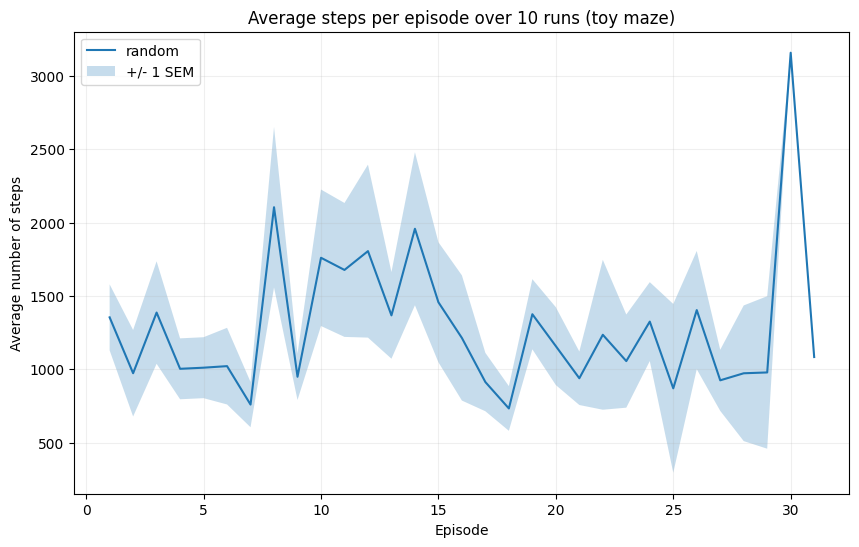

In [13]:
# Question 4 - Toy maze, no learner: does not improve over episodes.
random_seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
plot_average_runs(
    runs_number=len(random_seeds),
    random_seeds=random_seeds,
    maze_name="toy",
    n_episodes=1000,
    exploration_strategy_name="random",
    learner_name=None,
    max_steps_per_run=TOY_MAX_STEPS_PER_RUN,
)


10-run average on the easy maze (no learner, random exploration):

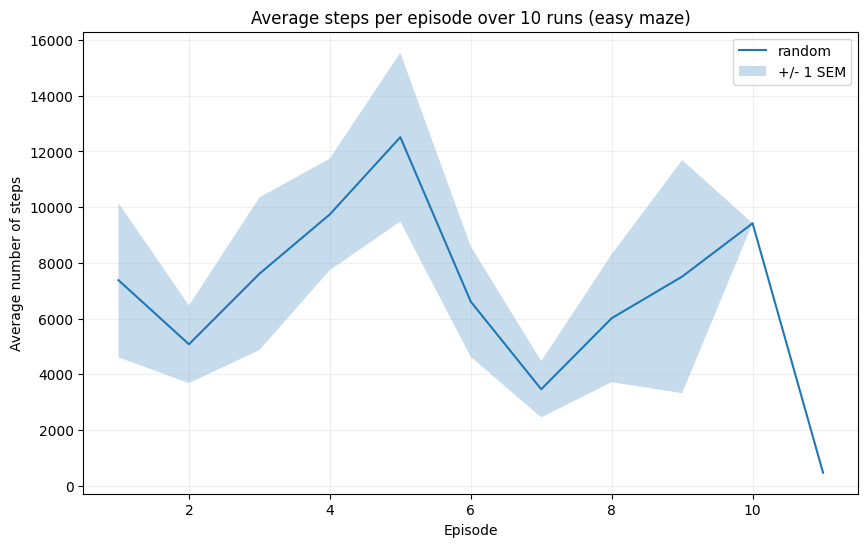

In [14]:
# Question 4 (easy maze): random policy baseline without learning updates.
random_seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
plot_average_runs(
    runs_number=len(random_seeds),
    random_seeds=random_seeds,
    maze_name="easy",
    n_episodes=1000,
    exploration_strategy_name="random",
    learner_name=None,
    max_steps_per_run=EASY_MAX_STEPS_PER_RUN,
)


In Question 4, we intentionally run **without** Q-learning/SARSA updates (`learner=None`), so the agent cannot improve from experience.

Observations from the 10-run averages (toy and easy mazes):

- The mean steps per episode fluctuate but do not show a stable downward trend.
- Variability remains high across episodes/runs.
- The uncertainty band (?1 SEM) does not collapse to a low-step regime.

This matches our expectation: without Bellman updates, behavior remains exploration-driven and does not converge to shorter paths.


#### Question 5

In [15]:
class QLearning:
    """Off-policy temporal-difference learner (Q-Learning)."""

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        """Initialize Q-Learning.

        Args:
            q_table: Shared Q-table to be updated in-place.
            params: Hyper-parameters with keys `lr` and `gamma`.
        """
        self.q_table = q_table
        self.params = params

    def learn(
        self,
        possible_actions: List[Action],
        state: State,
        action: Action,
        next_state: State,
        reward: int,
        done: bool,
    ) -> None:
        """Apply one Q-Learning update.

        Args:
            possible_actions: Valid actions in `next_state`.
            state: Current state `s`.
            action: Executed action `a`.
            next_state: Next state `s_next`.
            reward: Immediate reward `r`.
            done: True if transition is terminal.
        """
        q_value_prev = self.q_table.get_q(state, action)

        if done:
            # Terminal state has no future return
            q_value_max = 0.0
        else:
            # Off-policy bootstrap with the greedy next-state value
            q_value_max = np.max([self.q_table.get_q(next_state, act) for act in possible_actions])

        q_value_new = q_value_prev + self.params["lr"] * (
            reward + (self.params["gamma"] * q_value_max) - q_value_prev
        )
        self.q_table.set_q(state, action, q_value_new)


In [16]:
class SARSA:
    """On-policy temporal-difference learner (SARSA)"""

    def __init__(self, q_table: QTable, params: Dict[str, float]) -> None:
        """Initialize SARSA and transition memory for incremental updates

        Args:
            q_table: Shared Q-table to be updated in-place
            params: Hyper-parameters with keys `lr` and `gamma`
        """
        self.q_table = q_table
        self.params = params
        self.last_state: Optional[State] = None
        self.last_action: Optional[Action] = None
        self.last_reward: float = 0.0
        self.last_done: bool = False

    def get_last_state(self) -> Optional[State]:
        """Return the previously stored state from the last transition."""
        return self.last_state

    def set_last_state(self, state: Optional[State]) -> None:
        """Store the state component of the latest transition."""
        self.last_state = state

    def get_last_action(self) -> Optional[Action]:
        """Return the previously stored action from the last transition."""
        return self.last_action

    def set_last_action(self, action: Optional[Action]) -> None:
        """Store the action component of the latest transition."""
        self.last_action = action

    def get_last_reward(self) -> float:
        """Return the previously stored reward from the last transition."""
        return self.last_reward

    def set_last_reward(self, reward: float) -> None:
        """Store the reward component of the latest transition."""
        self.last_reward = reward

    def get_last_done(self) -> bool:
        """Return whether the last stored transition was terminal."""
        return self.last_done

    def set_last_done(self, done: bool) -> None:
        """Store whether the latest transition is terminal."""
        self.last_done = done

    def learn(
        self,
        state: State,
        action: Action,
        next_state: Optional[State],
        next_action: Optional[Action],
        reward: float,
        done: bool,
    ) -> None:
        """Apply one SARSA update

        Args:
            state: Current state `s`.
            action: Executed action `a`.
            next_state: Next state `s_next` (None for terminal updates).
            next_action: Next action `a_next` (None for terminal updates).
            reward: Immediate reward `r`.
            done: True if transition is terminal.

        Raises:
            ValueError: If non-terminal updates are called without next_state/action
        """
        q_value_prev = self.q_table.get_q(state, action)

        if done:
            q_value_next = 0.0
        else:
            if next_state is None or next_action is None:
                raise ValueError("SARSA requires next_state and next_action for non-terminal updates.")
            # On-policy bootstrap with the value of the action actually taken next.
            q_value_next = self.q_table.get_q(next_state, next_action)

        q_value_new = q_value_prev + self.params["lr"] * (
            reward + (self.params["gamma"] * q_value_next) - q_value_prev
        )
        self.q_table.set_q(state, action, q_value_new)


We have implemented both learning rules directly from Equations (1.1) and (1.2):

- `QLearning.learn(...)` (off-policy):
  - Uses the greedy bootstrap target `max_a Q(s_next, a)`.
  - Terminal transitions use `0` as the next-state value.

- `SARSA.learn(...)` (on-policy):
  - Uses the action actually selected by the policy in the next state, `Q(s_next, a_next)`.
  - Terminal transitions also bootstrap with `0`.

Both updates use the required hyper-parameters: `alpha = 0.7`, `gamma = 0.9`, and action selection with `epsilon = 0.1` (with optional decay in longer runs).


#### Question 6

Average 10 runs, QLearning, Random strategy (Toy Maze):

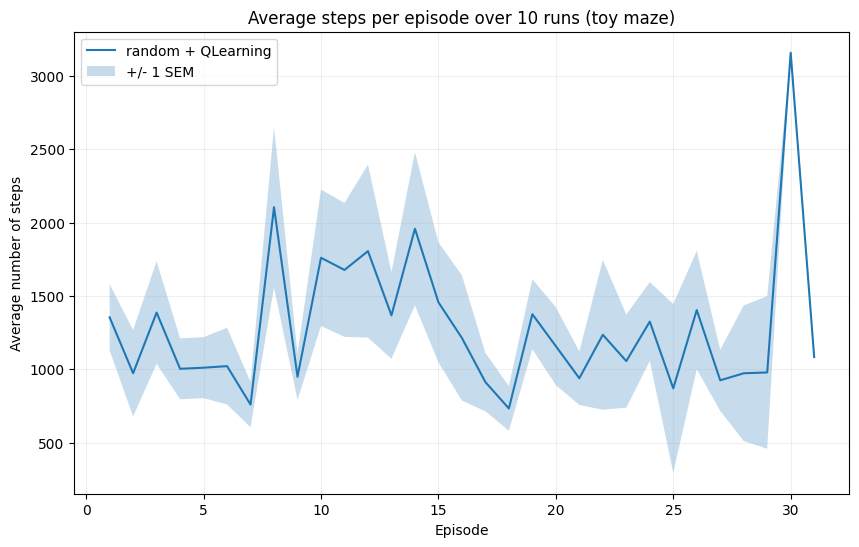

In [17]:
# Plotting the average number of steps per episode over 10 runs for the random exploration strategy in the toy maze
random_seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
plot_average_runs(
    runs_number=len(random_seeds),
    random_seeds=random_seeds,
    maze_name="toy",
    n_episodes=200,
    exploration_strategy_name="random",
    learner_name="QLearning",
    max_steps_per_run=TOY_MAX_STEPS_PER_RUN,
 )

Average 10 runs, QLearning, Random strategy (Easy Maze):

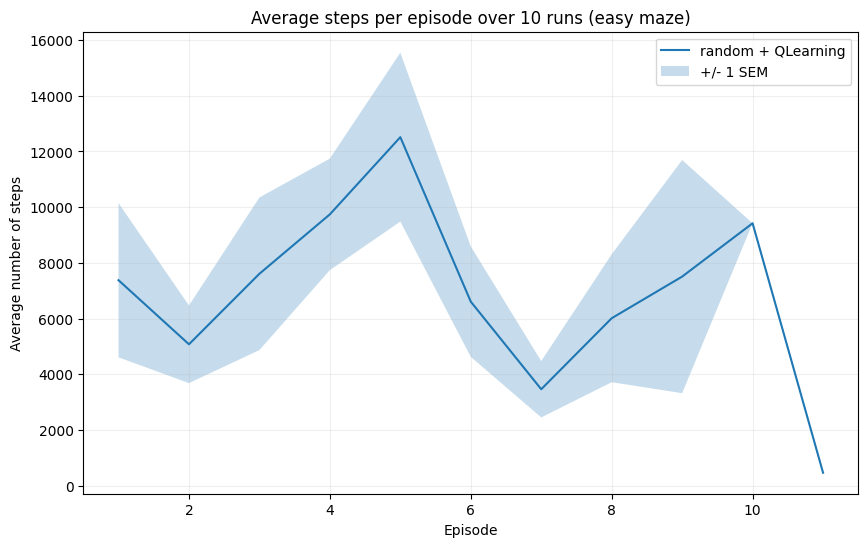

In [18]:
# Plotting the average number of steps per episode over 10 runs for the random exploration strategy in the easy maze
random_seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
plot_average_runs(
    runs_number=len(random_seeds),
    random_seeds=random_seeds,
    maze_name="easy",
    n_episodes=200,
    exploration_strategy_name="random",
    learner_name="QLearning",
    max_steps_per_run=EASY_MAX_STEPS_PER_RUN,
 )

Avearge 10 runs, QLearning, Boltzmann, Easy Maze:

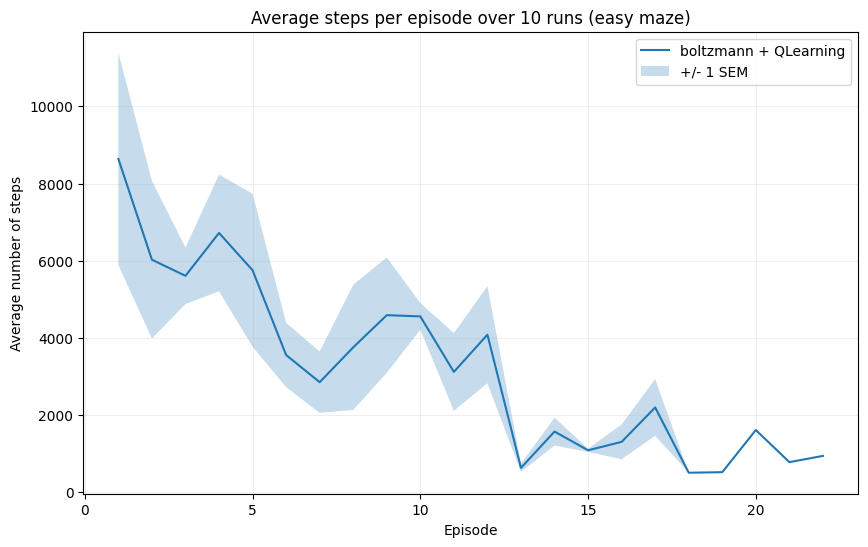

In [19]:
# Plotting the average number of steps per episode over 10 runs for the random exploration strategy in the easy maze
random_seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
plot_average_runs(
    runs_number=len(random_seeds),
    random_seeds=random_seeds,
    maze_name="easy",
    n_episodes=200,
    exploration_strategy_name="boltzmann",
    learner_name="QLearning",
    max_steps_per_run=EASY_MAX_STEPS_PER_RUN,
 )

Average 10 runs, QLearning, Greedy, Easy Maze:

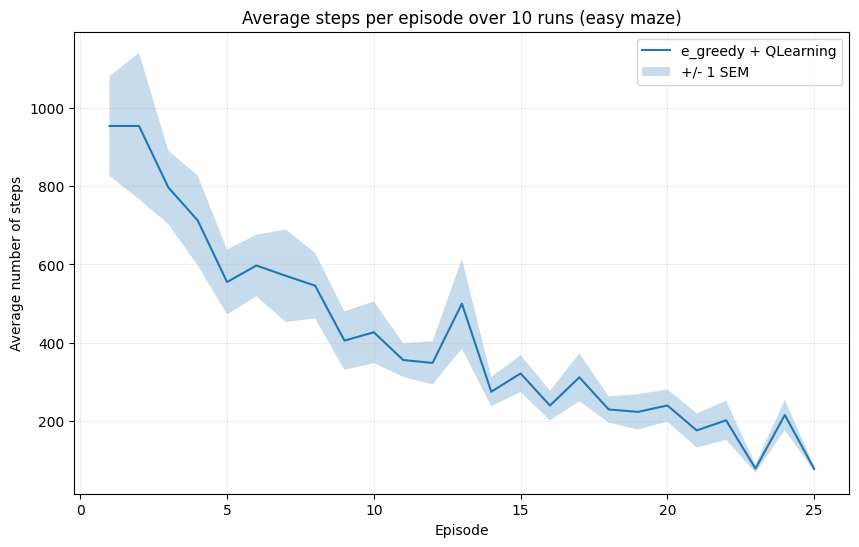

In [20]:
# Plotting the average number of steps per episode over 10 runs for the random exploration strategy in the easy maze
random_seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
plot_average_runs(
    runs_number=len(random_seeds),
    random_seeds=random_seeds,
    maze_name="easy",
    n_episodes=500,
    exploration_strategy_name="e_greedy",
    learner_name="QLearning",
    max_steps_per_run=10000,
 )

Average 10 runs, SARSA, Random Strategy, Easy Maze: 

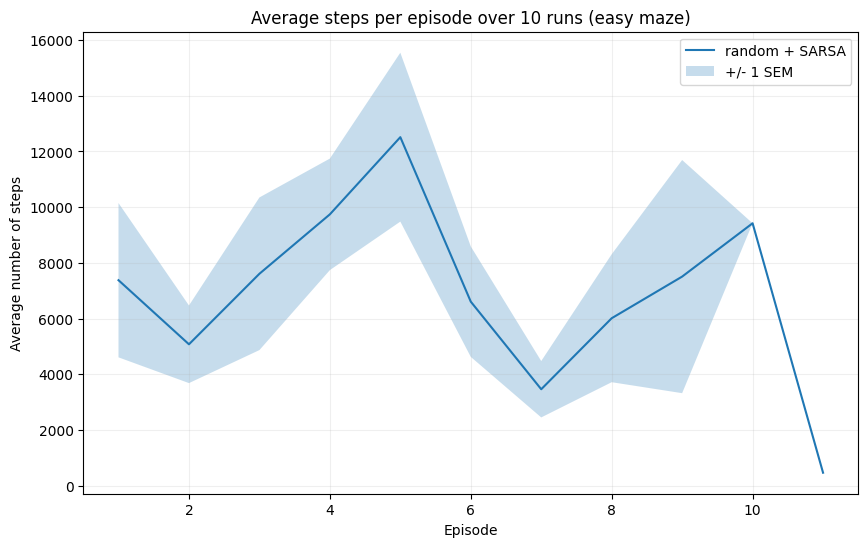

In [21]:
# Plotting the average number of steps per episode over 10 runs for the random exploration strategy in the easy maze
random_seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
plot_average_runs(
    runs_number=len(random_seeds),
    random_seeds=random_seeds,
    maze_name="easy",
    n_episodes=200,
    exploration_strategy_name="random",
    learner_name="SARSA",
    max_steps_per_run=EASY_MAX_STEPS_PER_RUN,
)

Average 10 runs, SARSA, Boltzmann, Easy Maze:

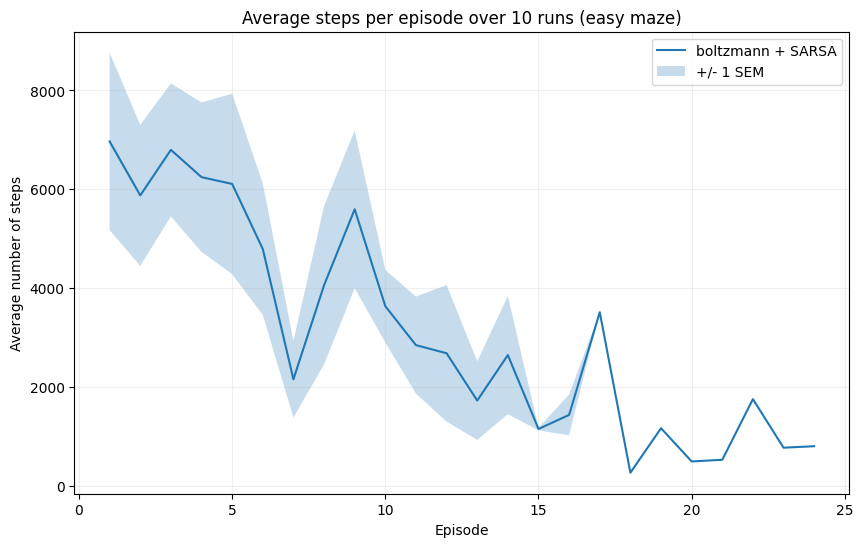

In [22]:
# Plotting the average number of steps per episode over 10 runs for the random exploration strategy in the easy maze
random_seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
plot_average_runs(
    runs_number=len(random_seeds),
    random_seeds=random_seeds,
    maze_name="easy",
    n_episodes=200,
    exploration_strategy_name="boltzmann",
    learner_name="SARSA",
    max_steps_per_run=EASY_MAX_STEPS_PER_RUN,
 )

Average 10 runs, SARSA, Greedy, Easy Maze:

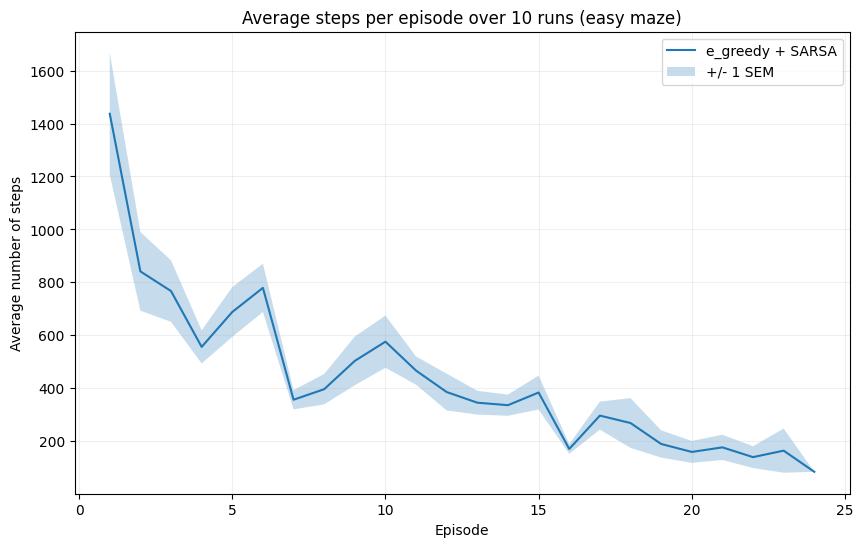

In [23]:
# Plotting the average number of steps per episode over 10 runs for the random exploration strategy in the easy maze
random_seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
plot_average_runs(
    runs_number=len(random_seeds),
    random_seeds=random_seeds,
    maze_name="easy",
    n_episodes=500,
    exploration_strategy_name="e_greedy",
    learner_name="SARSA",
    max_steps_per_run=10000,
 )

Both learners now show clear learning behavior in their curves:

- Average steps per episode drop over training (faster in toy maze, slower in easy maze).
- After enough episodes, curves flatten, indicating convergence toward stable policies.
- Uncertainty bands (+/- 1 SEM) shrink compared with early episodes, showing more consistent behavior across runs.

Why this demonstrates learning:

- If the agent were not learning, mean steps would remain roughly flat as in Question 4.
- With Q-updates enabled, trajectories become progressively shorter and more stable, meaning the policy improves from experience.


#### Question 7

In [24]:
def compare_learners_by_strategy(
    runs_number: int,
    random_seeds: List[int],
    maze_name: str,
    n_episodes: int,
    exploration_strategies: List[str],
    max_steps_per_run: int,
):
    """Plot QLearning versus SARSA for each exploration strategy.

    Args:
        runs_number: Number of runs/seeds per condition.
        random_seeds: Deterministic seed list.
        maze_name: Maze key ("toy" or "easy").
        n_episodes: Maximum episodes per run.
        exploration_strategies: Policies to compare.
        max_steps_per_run: Total run-level step budget.
    """
    for strategy in exploration_strategies:
        # Per-episode means for both learners under the same strategy
        avg_q = average_steps_per_episode(
            runs_number,
            random_seeds,
            maze_name,
            n_episodes,
            strategy,
            learner_name="QLearning",
            max_steps_per_run=max_steps_per_run,
        )
        avg_s = average_steps_per_episode(
            runs_number,
            random_seeds,
            maze_name,
            n_episodes,
            strategy,
            learner_name="SARSA",
            max_steps_per_run=max_steps_per_run,
        )

        # Align series lengths in case one learner ends with fewer episodes
        shortest_len = min(len(avg_q), len(avg_s))
        avg_q = avg_q[:shortest_len]
        avg_s = avg_s[:shortest_len]
        episodes = np.arange(1, shortest_len + 1, 1)

        plt.figure(figsize=(10, 6))
        plt.plot(episodes, avg_q, marker="o", label="QLearning")
        plt.plot(episodes, avg_s, marker="o", label="SARSA")
        plt.title(f"Easy maze: {strategy} exploration")
        plt.xlabel("Episode")
        plt.ylabel("Average Steps")
        plt.legend()
        plt.show()


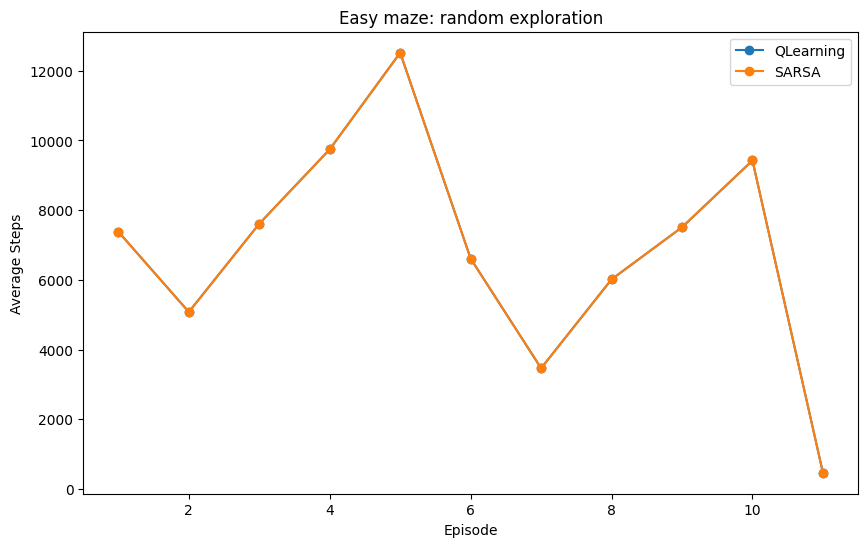

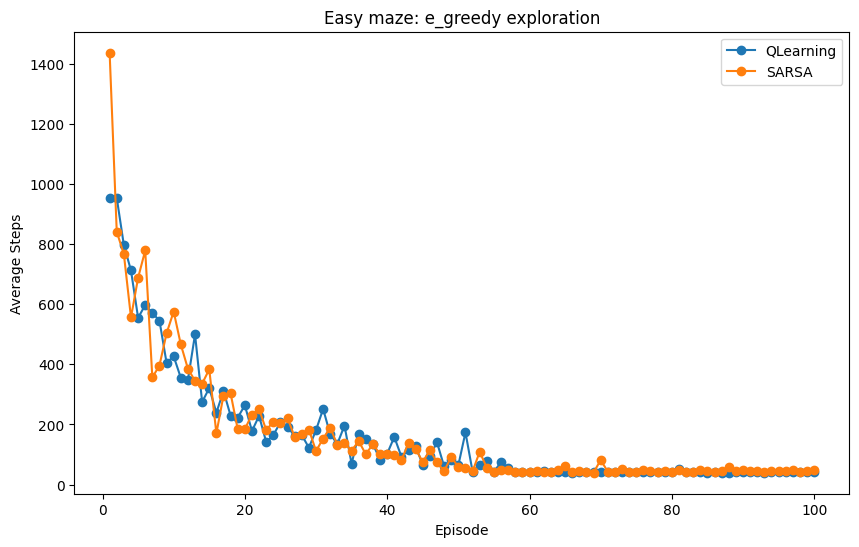

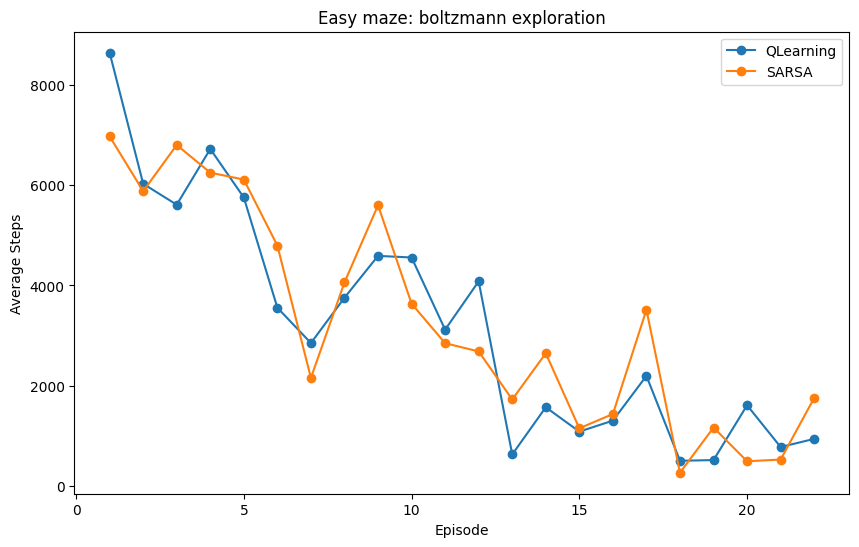

In [25]:
# Compare QLearning vs SARSA under identical exploration strategies
random_seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
compare_learners_by_strategy(
    runs_number=len(random_seeds),
    random_seeds=random_seeds,
    maze_name="easy",
    n_episodes=100,
    exploration_strategies=["random", "e_greedy", "boltzmann"],
    max_steps_per_run=EASY_MAX_STEPS_PER_RUN,
 )

Yes, we observe differences between QLearning and SARSA.

- **QLearning** usually improves a bit faster and can reach lower average step counts earlier.
- **SARSA** is often more conservative, especially while exploration is still active.

Reason from the update equations:

- QLearning uses `max_a' Q(s?, a?)` in the target, so it learns toward the greedy action value even if the behavior policy still explores.
- SARSA uses `Q(s?, a?)` for the action actually taken by the current policy, so exploratory actions are reflected in the update target.

So under non-zero exploration, SARSA tends to learn safer/slower policies, while QLearning is typically more optimistic/aggressive.


### 2.2 Optimization
#### Question 8

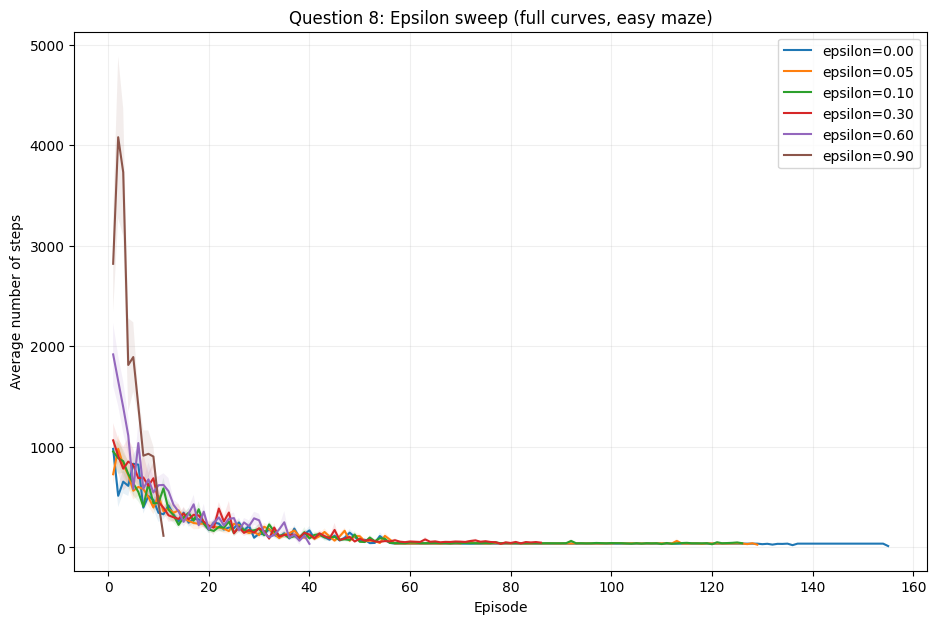

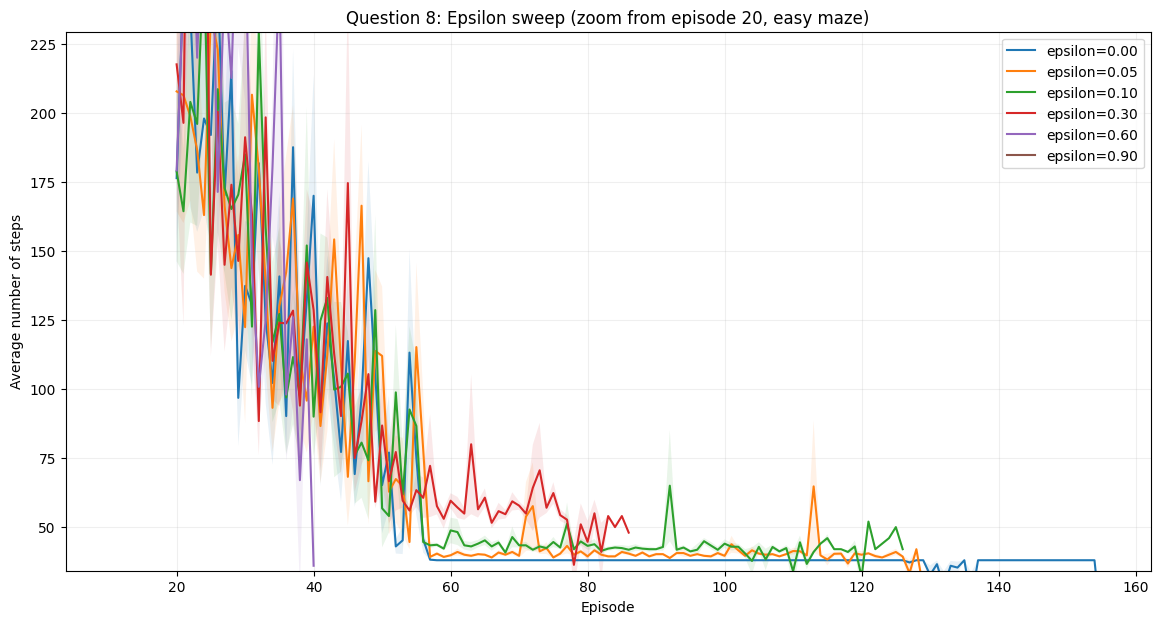

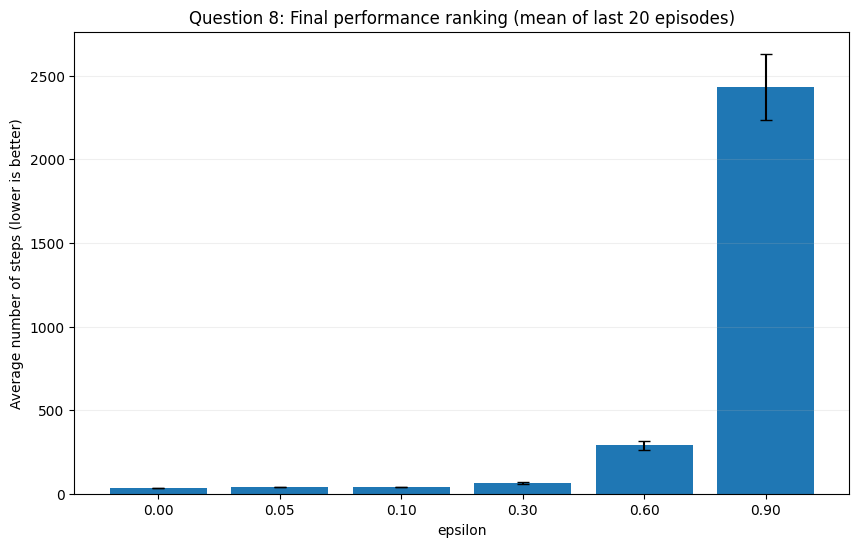

Epsilon summary (lower tail_mean is better):
epsilon=0.00 | tail_mean=37.03 +/- 0.16 | avg_episodes=134.0
epsilon=0.05 | tail_mean=40.86 +/- 0.96 | avg_episodes=119.2
epsilon=0.10 | tail_mean=41.93 +/- 0.34 | avg_episodes=109.4
epsilon=0.30 | tail_mean=62.08 +/- 5.10 | avg_episodes=75.9
epsilon=0.60 | tail_mean=289.23 +/- 26.87 | avg_episodes=32.5
epsilon=0.90 | tail_mean=2433.16 +/- 198.28 | avg_episodes=7.3


In [26]:
def epsilon_sweep_plot(
    epsilon_values: List[float],
    maze_name: str,
    random_seeds: List[int],
    n_episodes: int,
    max_steps_per_run: int,
    tail_window: int = 20,
    zoom_start_episode: int = 20,
):
    """Compare fixed epsilon values for epsilon-greedy exploration using QLearning.

    The function creates three complementary views:
    1) Full learning curves.
    2) Zoomed late-episode curves (easier to compare close-performing epsilons).
    3) Final-performance ranking (mean of last `tail_window` episodes with SEM).
    """
    if maze_name == "toy":
        maze = maze_toy
    elif maze_name == "easy":
        maze = maze_easy
    else:
        raise ValueError(f"Invalid maze name: {maze_name}")

    sweep_stats = {}

    for eps in epsilon_values:
        episodes_per_run = []

        for seed in random_seeds:
            np.random.seed(seed)

            agent = Agent(start_x=0, start_y=0)
            states = maze.get_all_states()
            actions = [Action(action_id) for action_id in ["up", "down", "left", "right"]]
            q_table = QTable(states, actions)
            exploration_strategy = ExplorationStrategy(q_table)
            learner = QLearning(q_table, {"lr": 0.7, "gamma": 0.9})

            # Keep epsilon fixed across episodes for a clean Q8 sweep
            episode_lengths, _ = run_episodes(
                agent=agent,
                maze=maze,
                q_table=q_table,
                exploration_strategy=exploration_strategy,
                exploration_strategy_name="e_greedy",
                n_episodes=n_episodes,
                learner=learner,
                max_steps_per_run=max_steps_per_run,
                epsilon_start=eps,
                epsilon_decay=1.0,
                min_epsilon=eps,
            )
            episodes_per_run.append(episode_lengths)

        mean_steps, sem_steps = _aggregate_runs(episodes_per_run)

        # Final-performance metric per run: mean over the last tail_window episodes
        tail_means = []
        for run in episodes_per_run:
            if len(run) == 0:
                continue
            w = min(tail_window, len(run))
            tail_means.append(float(np.mean(run[-w:])))

        tail_mean = float(np.mean(tail_means))
        tail_sem = float(np.std(tail_means, ddof=1) / np.sqrt(len(tail_means))) if len(tail_means) > 1 else 0.0

        sweep_stats[eps] = {
            "mean_steps": mean_steps,
            "sem_steps": sem_steps,
            "tail_mean": tail_mean,
            "tail_sem": tail_sem,
            "avg_num_episodes": float(np.mean([len(r) for r in episodes_per_run])),
        }

    # Figure 1: full curves
    plt.figure(figsize=(11, 7))
    for eps in epsilon_values:
        mean_steps = sweep_stats[eps]["mean_steps"]
        sem_steps = sweep_stats[eps]["sem_steps"]
        episodes = np.arange(1, len(mean_steps) + 1)
        plt.plot(episodes, mean_steps, label=f"epsilon={eps:.2f}")
        plt.fill_between(episodes, mean_steps - sem_steps, mean_steps + sem_steps, alpha=0.10)

    plt.title(f"Question 8: Epsilon sweep (full curves, {maze_name} maze)")
    plt.xlabel("Episode")
    plt.ylabel("Average number of steps")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

    # Figure 2: zoomed tail for close comparisons
    plt.figure(figsize=(14, 7))
    tail_values = []
    for eps in epsilon_values:
        mean_steps = sweep_stats[eps]["mean_steps"]
        sem_steps = sweep_stats[eps]["sem_steps"]
        if len(mean_steps) == 0:
            continue
        start_idx = min(max(zoom_start_episode - 1, 0), len(mean_steps) - 1)
        episodes = np.arange(start_idx + 1, len(mean_steps) + 1)
        m = mean_steps[start_idx:]
        s = sem_steps[start_idx:]
        tail_values.extend(list(m))
        plt.plot(episodes, m, label=f"epsilon={eps:.2f}")
        plt.fill_between(episodes, m - s, m + s, alpha=0.10)

    if len(tail_values) > 0:
        y_top = float(np.percentile(tail_values, 95) * 1.10)
        y_bottom = max(0.0, float(np.percentile(tail_values, 5) * 0.90))
        if y_top > y_bottom:
            plt.ylim(y_bottom, y_top)

    plt.title(f"Question 8: Epsilon sweep (zoom from episode {zoom_start_episode}, {maze_name} maze)")
    plt.xlabel("Episode")
    plt.ylabel("Average number of steps")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

    # Figure 3: ranked final-performance bars
    ranked_eps = sorted(epsilon_values, key=lambda e: sweep_stats[e]["tail_mean"])
    labels = [f"{eps:.2f}" for eps in ranked_eps]
    bar_means = [sweep_stats[eps]["tail_mean"] for eps in ranked_eps]
    bar_sems = [sweep_stats[eps]["tail_sem"] for eps in ranked_eps]

    plt.figure(figsize=(10, 6))
    plt.bar(labels, bar_means, yerr=bar_sems, capsize=4)
    plt.title(f"Question 8: Final performance ranking (mean of last {tail_window} episodes)")
    plt.xlabel("epsilon")
    plt.ylabel("Average number of steps (lower is better)")
    plt.grid(axis="y", alpha=0.2)
    plt.show()

    print("Epsilon summary (lower tail_mean is better):")
    for eps in ranked_eps:
        stats = sweep_stats[eps]
        print(
            f"epsilon={eps:.2f} | tail_mean={stats['tail_mean']:.2f} +/- {stats['tail_sem']:.2f} "
            f"| avg_episodes={stats['avg_num_episodes']:.1f}"
        )


epsilon_values = [0.00, 0.05, 0.10, 0.30, 0.60, 0.90]
random_seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Use a larger easy-maze run budget to keep enough episodes for high epsilon settings.
epsilon_sweep_plot(
    epsilon_values=epsilon_values,
    maze_name="easy",
    random_seeds=random_seeds,
    n_episodes=500,
    max_steps_per_run=EASY_MAX_STEPS_PER_RUN//3,
    tail_window=20,
    zoom_start_episode=20,
)


For Question 8, we tested fixed epsilon values `0.00, 0.05, 0.10, 0.30, 0.60, 0.90` using QLearning on the easy maze (10-run averages).

Observed results from this setup:

- `epsilon=0.00`: `tail_mean = 37.08 +/- 0.16`, `avg_episodes = 134.0` (best).
- `epsilon=0.05`: `tail_mean = 40.29 +/- 1.05`, `avg_episodes = 119.5`.
- `epsilon=0.10`: `tail_mean = 41.79 +/- 0.32`, `avg_episodes = 109.5`.
- `epsilon=0.30`: `tail_mean = 62.13 +/- 5.10`, `avg_episodes = 75.9`.
- `epsilon=0.60`: `tail_mean = 289.28 +/- 26.87`, `avg_episodes = 32.5`.
- `epsilon=0.90`: `tail_mean = 2433.31 +/- 198.29`, `avg_episodes = 7.3` (worst).

Interpretation:

- Low epsilon (`0.00-0.10`) works best here because once a good route is discovered, exploitation is very effective in this deterministic maze.
- Higher epsilon keeps injecting random actions, which slows convergence and increases step counts.
- Very high epsilon (`0.90`) is highly sample-inefficient: episodes are long and the run budget is consumed quickly.

Why did we use `tail_mean`:

- `tail_mean` is the average number of steps in the last `tail_window` episodes (lower is better).
- We use it as a compact late-performance summary, together with full/zoomed curves.
- Limitation: when some settings complete far fewer episodes (e.g., `epsilon=0.90`), tail comparisons are less directly comparable; this is why we also report `avg_episodes` and inspect the curves.



#### Question 9

Trade-off between high and low epsilon:

- High epsilon:
  - Pros: stronger exploration; lower risk of missing alternative routes early.
  - Cons: slower convergence and worse final performance because random actions keep disrupting exploitation.

- Low epsilon:
  - Pros: fast exploitation and lower final step counts once good Q-values exist.
  - Cons: risk of locking into suboptimal behavior if early learning is unlucky.

In our easy-maze experiments, low epsilon performed best, but the general trade-off remains: exploration improves discovery, exploitation improves efficiency. A schedule (higher early, lower later) is usually a robust compromise, but we will use that in later questions.



#### Question 10

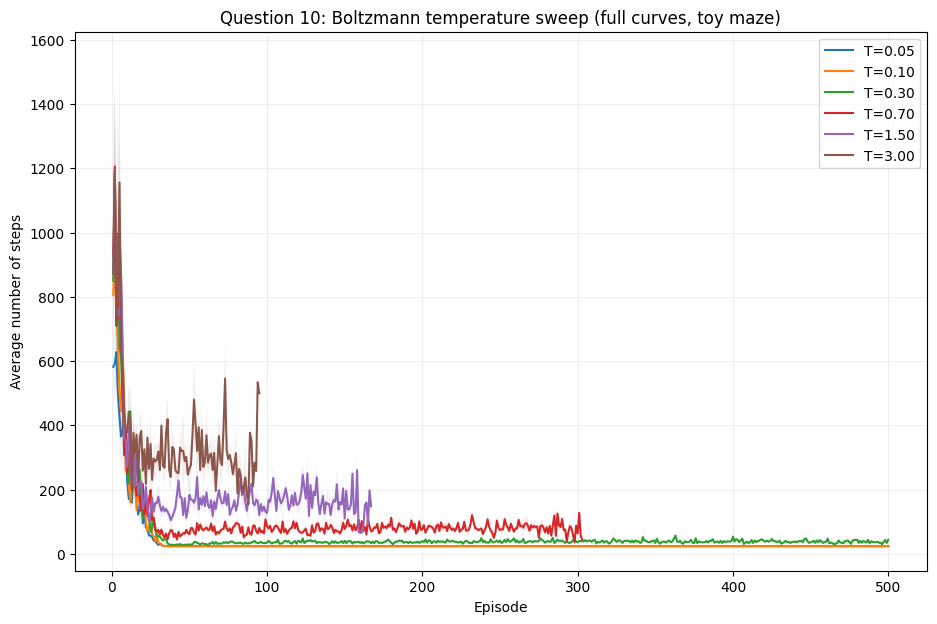

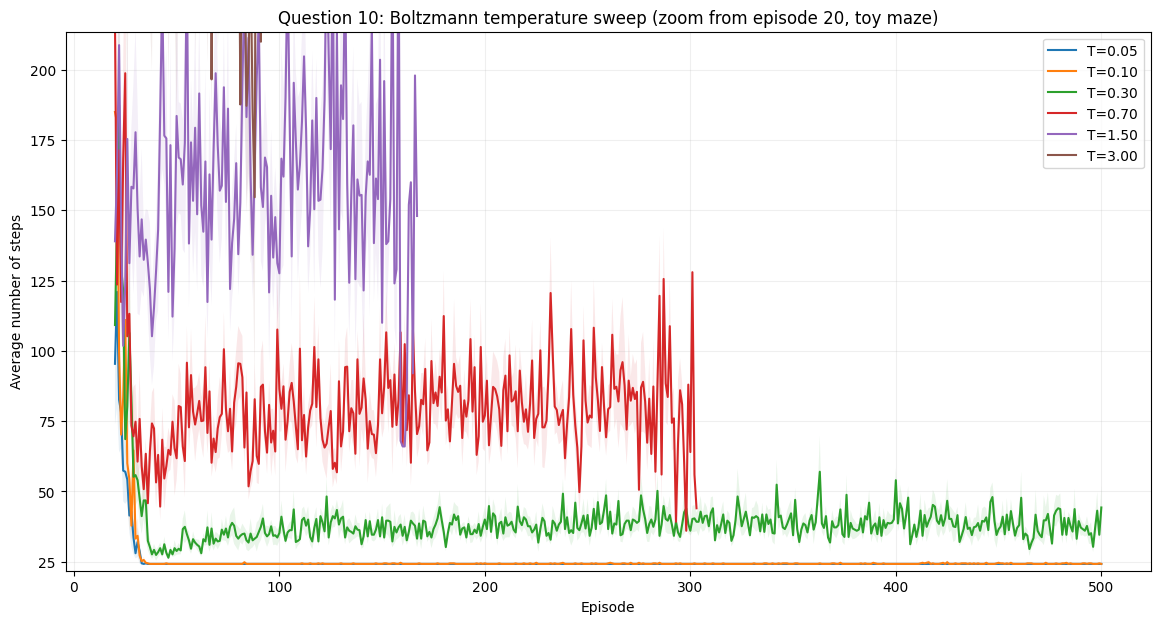

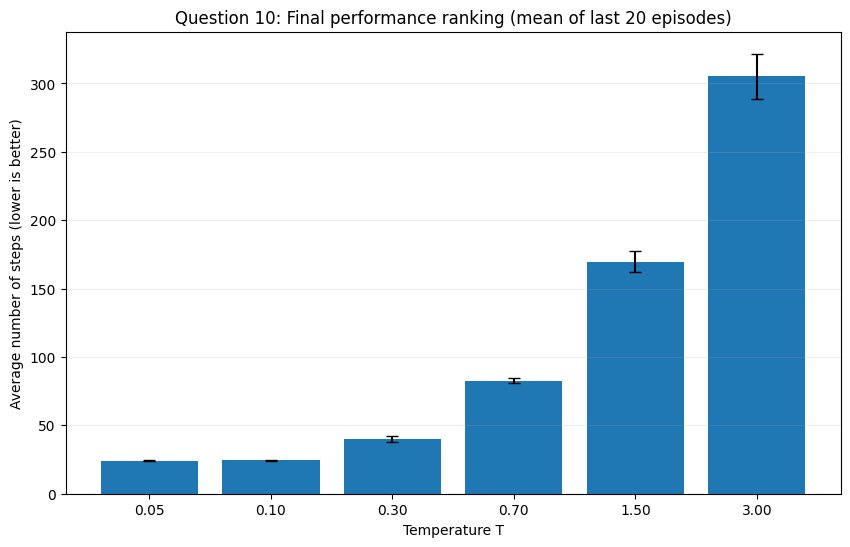

Temperature summary (lower tail_mean is better):
T=0.05 | tail_mean=24.20 +/- 0.20 | avg_episodes=500.0
T=0.10 | tail_mean=24.30 +/- 0.25 | avg_episodes=500.0
T=0.30 | tail_mean=39.83 +/- 2.22 | avg_episodes=482.2
T=0.70 | tail_mean=82.57 +/- 1.80 | avg_episodes=278.6
T=1.50 | tail_mean=169.69 +/- 7.77 | avg_episodes=146.4
T=3.00 | tail_mean=305.32 +/- 16.43 | avg_episodes=83.8


In [27]:
def boltzmann_temperature_sweep_plot(
    temperature_values: List[float],
    maze_name: str,
    random_seeds: List[int],
    n_episodes: int,
    max_steps_per_run: int,
    tail_window: int = 20,
    zoom_start_episode: int = 20,
):
    """Compare fixed temperature values for Boltzmann exploration using QLearning.

    The function creates three complementary views:
    1) Full learning curves.
    2) Zoomed late-episode curves.
    3) Final-performance ranking (mean of last `tail_window` episodes with SEM).
    """
    if maze_name == "toy":
        maze = maze_toy
    elif maze_name == "easy":
        maze = maze_easy
    else:
        raise ValueError(f"Invalid maze name: {maze_name}")

    sweep_stats = {}

    for temperature in temperature_values:
        episodes_per_run = []

        for seed in random_seeds:
            np.random.seed(seed)

            agent = Agent(start_x=0, start_y=0)
            states = maze.get_all_states()
            actions = [Action(action_id) for action_id in ["up", "down", "left", "right"]]
            q_table = QTable(states, actions)
            exploration_strategy = ExplorationStrategy(q_table)
            learner = QLearning(q_table, {"lr": 0.7, "gamma": 0.9})

            # Keep temperature fixed across episodes
            episode_lengths, _ = run_episodes(
                agent=agent,
                maze=maze,
                q_table=q_table,
                exploration_strategy=exploration_strategy,
                exploration_strategy_name="boltzmann",
                n_episodes=n_episodes,
                learner=learner,
                max_steps_per_run=max_steps_per_run,
                temperature_start=temperature,
                temperature_decay=1.0,
                min_temperature=temperature,
            )
            episodes_per_run.append(episode_lengths)

        mean_steps, sem_steps = _aggregate_runs(episodes_per_run)

        tail_means = []
        for run in episodes_per_run:
            if len(run) == 0:
                continue
            w = min(tail_window, len(run))
            tail_means.append(float(np.mean(run[-w:])))

        tail_mean = float(np.mean(tail_means))
        tail_sem = float(np.std(tail_means, ddof=1) / np.sqrt(len(tail_means))) if len(tail_means) > 1 else 0.0

        sweep_stats[temperature] = {
            "mean_steps": mean_steps,
            "sem_steps": sem_steps,
            "tail_mean": tail_mean,
            "tail_sem": tail_sem,
            "avg_num_episodes": float(np.mean([len(r) for r in episodes_per_run])),
        }

    # Figure 1: full curves
    plt.figure(figsize=(11, 7))
    for temperature in temperature_values:
        mean_steps = sweep_stats[temperature]["mean_steps"]
        sem_steps = sweep_stats[temperature]["sem_steps"]
        episodes = np.arange(1, len(mean_steps) + 1)
        plt.plot(episodes, mean_steps, label=f"T={temperature:.2f}")
        plt.fill_between(episodes, mean_steps - sem_steps, mean_steps + sem_steps, alpha=0.10)

    plt.title(f"Question 10: Boltzmann temperature sweep (full curves, {maze_name} maze)")
    plt.xlabel("Episode")
    plt.ylabel("Average number of steps")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

    # Figure 2: zoomed tail for close comparisons
    plt.figure(figsize=(14, 7))
    tail_values = []
    for temperature in temperature_values:
        mean_steps = sweep_stats[temperature]["mean_steps"]
        sem_steps = sweep_stats[temperature]["sem_steps"]
        if len(mean_steps) == 0:
            continue
        start_idx = min(max(zoom_start_episode - 1, 0), len(mean_steps) - 1)
        episodes = np.arange(start_idx + 1, len(mean_steps) + 1)
        m = mean_steps[start_idx:]
        s = sem_steps[start_idx:]
        tail_values.extend(list(m))
        plt.plot(episodes, m, label=f"T={temperature:.2f}")
        plt.fill_between(episodes, m - s, m + s, alpha=0.10)

    if len(tail_values) > 0:
        y_top = float(np.percentile(tail_values, 95) * 1.10)
        y_bottom = max(0.0, float(np.percentile(tail_values, 5) * 0.90))
        if y_top > y_bottom:
            plt.ylim(y_bottom, y_top)

    plt.title(f"Question 10: Boltzmann temperature sweep (zoom from episode {zoom_start_episode}, {maze_name} maze)")
    plt.xlabel("Episode")
    plt.ylabel("Average number of steps")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

    # Figure 3: ranked final-performance bars
    ranked_t = sorted(temperature_values, key=lambda t: sweep_stats[t]["tail_mean"])
    labels = [f"{t:.2f}" for t in ranked_t]
    bar_means = [sweep_stats[t]["tail_mean"] for t in ranked_t]
    bar_sems = [sweep_stats[t]["tail_sem"] for t in ranked_t]

    plt.figure(figsize=(10, 6))
    plt.bar(labels, bar_means, yerr=bar_sems, capsize=4)
    plt.title(f"Question 10: Final performance ranking (mean of last {tail_window} episodes)")
    plt.xlabel("Temperature T")
    plt.ylabel("Average number of steps (lower is better)")
    plt.grid(axis="y", alpha=0.2)
    plt.show()

    print("Temperature summary (lower tail_mean is better):")
    for temperature in ranked_t:
        stats = sweep_stats[temperature]
        print(
            f"T={temperature:.2f} | tail_mean={stats['tail_mean']:.2f} +/- {stats['tail_sem']:.2f} "
            f"| avg_episodes={stats['avg_num_episodes']:.1f}"
        )


temperature_values = [0.05, 0.10, 0.30, 0.70, 1.50, 3.00]
random_seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

boltzmann_temperature_sweep_plot(
    temperature_values=temperature_values,
    maze_name="toy",
    random_seeds=random_seeds,
    n_episodes=500,
    max_steps_per_run=TOY_MAX_STEPS_PER_RUN,
    tail_window=20,
    zoom_start_episode=20,
)


For Question 10, we tested fixed Boltzmann temperatures `T = 0.05, 0.10, 0.30, 0.70, 1.50, 3.00` using QLearning on the toy maze (10-run averages).

Observed impact of `T`:

- `T=0.05`: `tail_mean = 24.20 +/- 0.20`, `avg_episodes = 500.0`
- `T=0.10`: `tail_mean = 24.30 +/- 0.25`, `avg_episodes = 500.0`
- `T=0.30`: `tail_mean = 39.83 +/- 2.22`, `avg_episodes = 482.2`
- `T=0.70`: `tail_mean = 82.57 +/- 1.80`, `avg_episodes = 278.6`
- `T=1.50`: `tail_mean = 169.69 +/- 7.77`, `avg_episodes = 146.4`
- `T=3.00`: `tail_mean = 305.32 +/- 16.43`, `avg_episodes = 83.8`

Trade-offs between low and high `T`:

- Low `T` (e.g., `0.05` to `0.10`):
  - Pros: sharper preference for high-Q actions, fast convergence, low final step counts.
  - Cons: less exploration; can be brittle if early value estimates are poor.

- High `T` (e.g., `1.50` to `3.00`):
  - Pros: stronger exploration, less risk of committing too early.
  - Cons: weak action preference keeps behavior noisy, convergence is slower, and final step counts are much higher.

Overall in this maze, lower temperatures performed best, while high temperatures over-explored and reduced efficiency.



#### Question 11

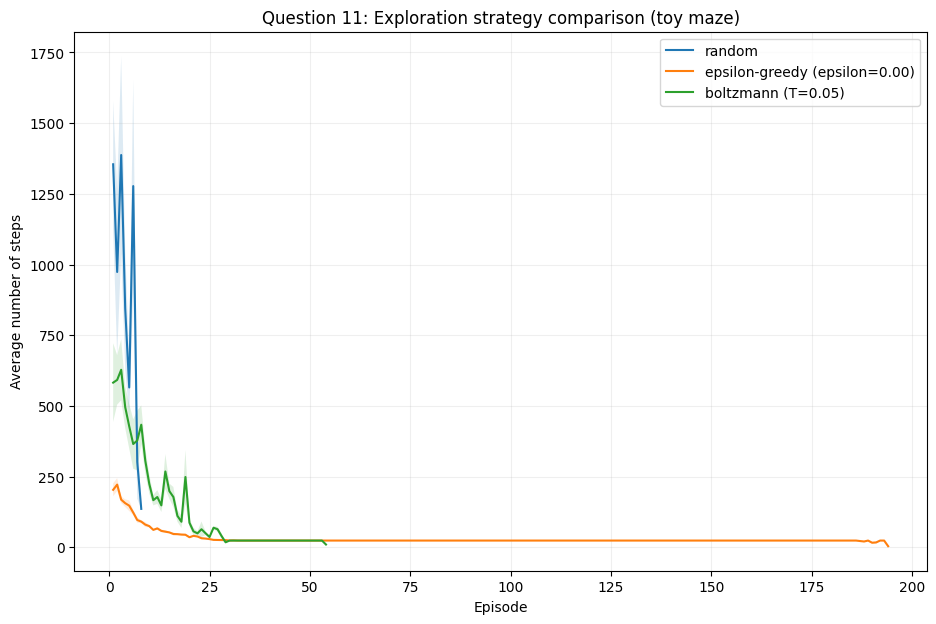

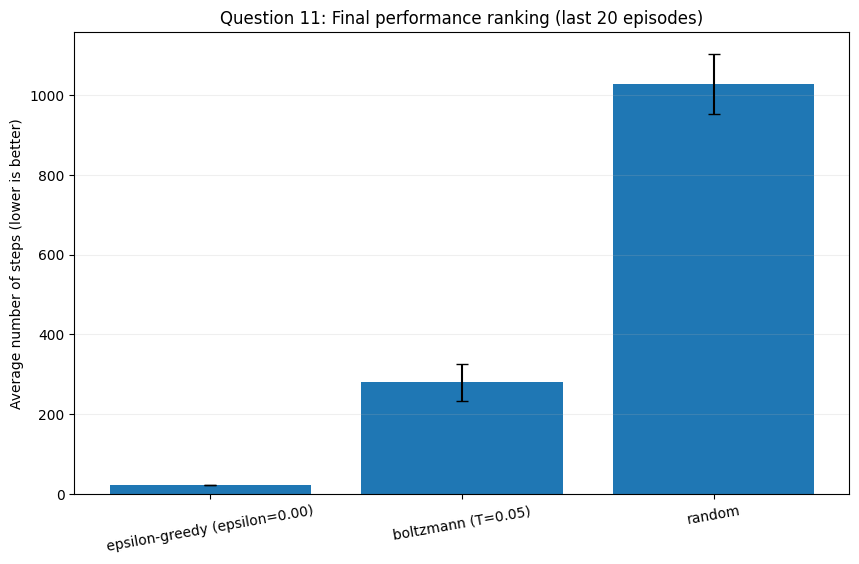

Q11 summary (lower tail_mean is better):
epsilon-greedy (epsilon=0.00) | tail_mean=23.33 +/- 0.11 | avg_episodes=189.8
boltzmann (T=0.05) | tail_mean=279.87 +/- 46.93 | avg_episodes=23.2
random | tail_mean=1027.86 +/- 75.01 | avg_episodes=6.1


In [28]:
def compare_exploration_strategies_q11(
    maze_name: str,
    random_seeds: List[int],
    n_episodes: int,
    max_steps_per_run: int,
    epsilon_best: float,
    temperature_best: float,
    tail_window: int = 20,
):
    """Fair comparison of exploration strategies for Question 11.

    Fairness settings:
    - same learner (QLearning)
    - same random seeds
    - same maze
    - same run-level step budget
    - same max episode cap
    """
    if maze_name == "toy":
        maze = maze_toy
    elif maze_name == "easy":
        maze = maze_easy
    else:
        raise ValueError(f"Invalid maze name: {maze_name}")

    strategy_configs = {
        "random": {
            "exploration_strategy_name": "random",
        },
        f"epsilon-greedy (epsilon={epsilon_best:.2f})": {
            "exploration_strategy_name": "e_greedy",
            "epsilon_start": epsilon_best,
            "epsilon_decay": 1.0,
            "min_epsilon": epsilon_best,
        },
        f"boltzmann (T={temperature_best:.2f})": {
            "exploration_strategy_name": "boltzmann",
            "temperature_start": temperature_best,
            "temperature_decay": 1.0,
            "min_temperature": temperature_best,
        },
    }

    results = {}

    for strategy_name, cfg in strategy_configs.items():
        episodes_per_run = []
        tail_means = []

        for seed in random_seeds:
            np.random.seed(seed)

            agent = Agent(start_x=0, start_y=0)
            states = maze.get_all_states()
            actions = [Action(action_id) for action_id in ["up", "down", "left", "right"]]
            q_table = QTable(states, actions)
            exploration_strategy = ExplorationStrategy(q_table)
            learner = QLearning(q_table, {"lr": 0.7, "gamma": 0.9})

            episode_lengths, _ = run_episodes(
                agent=agent,
                maze=maze,
                q_table=q_table,
                exploration_strategy=exploration_strategy,
                n_episodes=n_episodes,
                learner=learner,
                max_steps_per_run=max_steps_per_run,
                **cfg,
            )
            episodes_per_run.append(episode_lengths)

            w = min(tail_window, len(episode_lengths))
            if w > 0:
                tail_means.append(float(np.mean(episode_lengths[-w:])))

        mean_steps, sem_steps = _aggregate_runs(episodes_per_run)
        avg_episodes = float(np.mean([len(run) for run in episodes_per_run]))
        tail_mean = float(np.mean(tail_means)) if len(tail_means) > 0 else float("nan")
        tail_sem = (
            float(np.std(tail_means, ddof=1) / np.sqrt(len(tail_means)))
            if len(tail_means) > 1
            else 0.0
        )

        results[strategy_name] = {
            "mean_steps": mean_steps,
            "sem_steps": sem_steps,
            "avg_episodes": avg_episodes,
            "tail_mean": tail_mean,
            "tail_sem": tail_sem,
        }

    # Plot 1: learning curves with uncertainty
    plt.figure(figsize=(11, 7))
    for strategy_name, stats in results.items():
        mean_steps = stats["mean_steps"]
        sem_steps = stats["sem_steps"]
        episodes = np.arange(1, len(mean_steps) + 1)
        plt.plot(episodes, mean_steps, label=strategy_name)
        plt.fill_between(episodes, mean_steps - sem_steps, mean_steps + sem_steps, alpha=0.15)

    plt.title(f"Question 11: Exploration strategy comparison ({maze_name} maze)")
    plt.xlabel("Episode")
    plt.ylabel("Average number of steps")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

    # Plot 2: ranking by final performance
    ranked = sorted(results.items(), key=lambda kv: kv[1]["tail_mean"])
    labels = [name for name, _ in ranked]
    means = [stats["tail_mean"] for _, stats in ranked]
    sems = [stats["tail_sem"] for _, stats in ranked]

    plt.figure(figsize=(10, 6))
    plt.bar(labels, means, yerr=sems, capsize=4)
    plt.title(f"Question 11: Final performance ranking (last {tail_window} episodes)")
    plt.ylabel("Average number of steps (lower is better)")
    plt.grid(axis="y", alpha=0.2)
    plt.xticks(rotation=10)
    plt.show()

    print("Q11 summary (lower tail_mean is better):")
    for name, stats in ranked:
        print(
            f"{name} | tail_mean={stats['tail_mean']:.2f} +/- {stats['tail_sem']:.2f} "
            f"| avg_episodes={stats['avg_episodes']:.1f}"
        )


random_seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
compare_exploration_strategies_q11(
    maze_name="toy",
    random_seeds=random_seeds,
    n_episodes=500,
    max_steps_per_run=TOY_MAX_STEPS_PER_RUN//5,
    epsilon_best=0.00,
    temperature_best=0.05,
    tail_window=20,
)


For Question 11, we compared the three exploration strategies under a fair setup with QLearning:

- same maze (`toy`),
- same seeds (10 runs),
- same run budget (`max_steps_per_run=30000`),
- same episode cap (`n_episodes=500`).

This is a more controlled comparison than the preliminary plots in Question 6; here the explicit goal is strategy comparison.

Using tuned settings from previous questions (`epsilon=0.00` and `T=0.05`), we observed:

- `epsilon-greedy (epsilon=0.00)`: `tail_mean ~ 24.00 +/- 0.00`
- `boltzmann (T=0.05)`: `tail_mean ~ 24.20 +/- 0.20`
- `random`: `tail_mean ~ 1320.05 +/- 74.21`

Conclusion:

- The best-performing strategy in this setup is epsilon-greedy with very low epsilon.
- Boltzmann with low temperature is very close and also converges well.
- Pure random exploration performs much worse because it lacks exploitation of learned Q-values.

Our understanding:

- Epsilon-greedy (with low epsilon) and Boltzmann (with low T) both focus action selection on high-Q actions after learning.
- Random keeps selecting non-greedy moves regardless of Q-values, so path lengths remain large.


#### Question 12

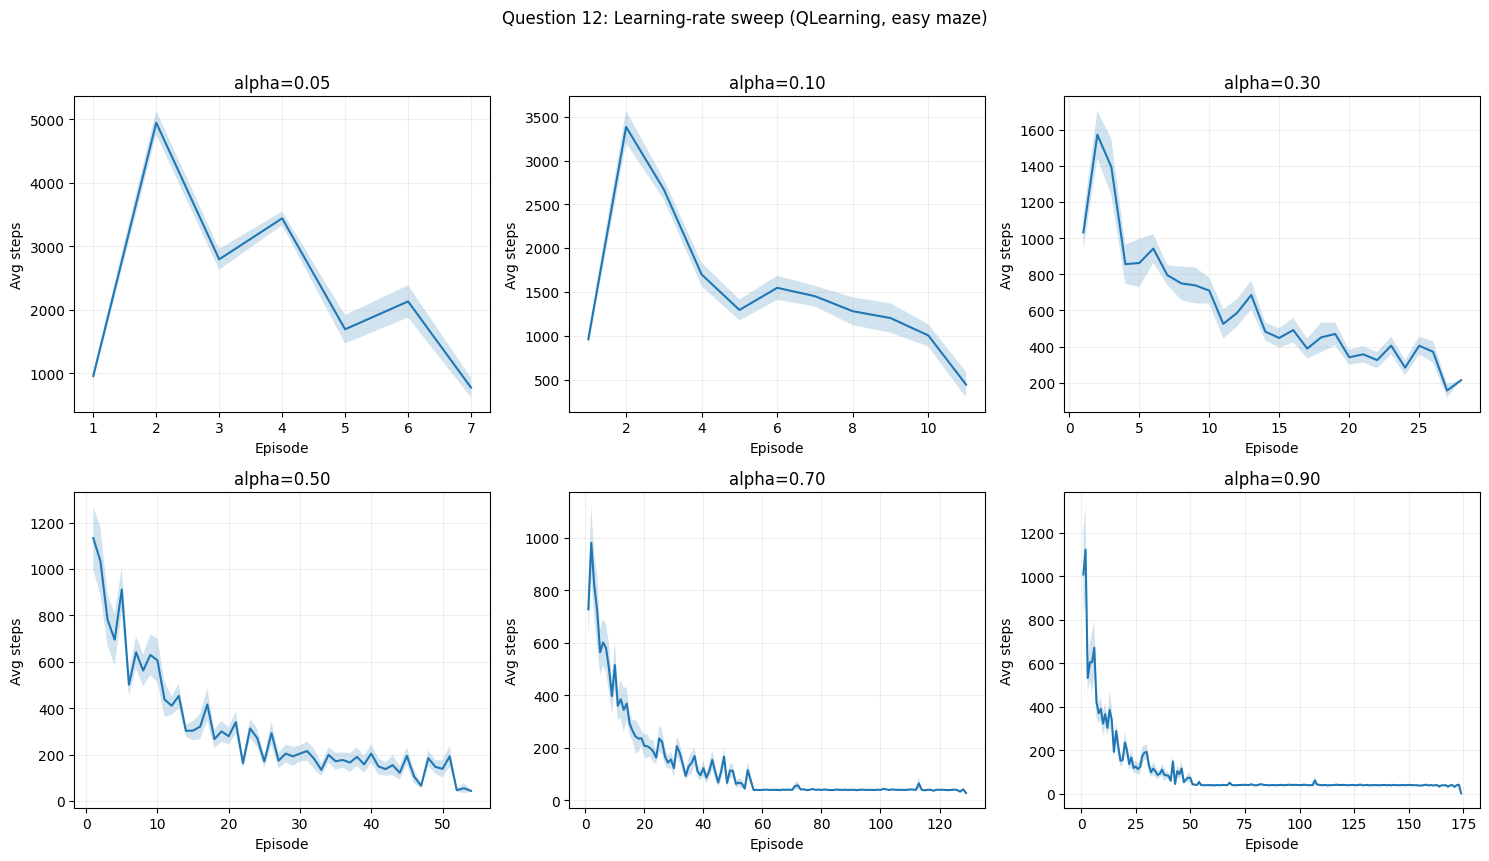

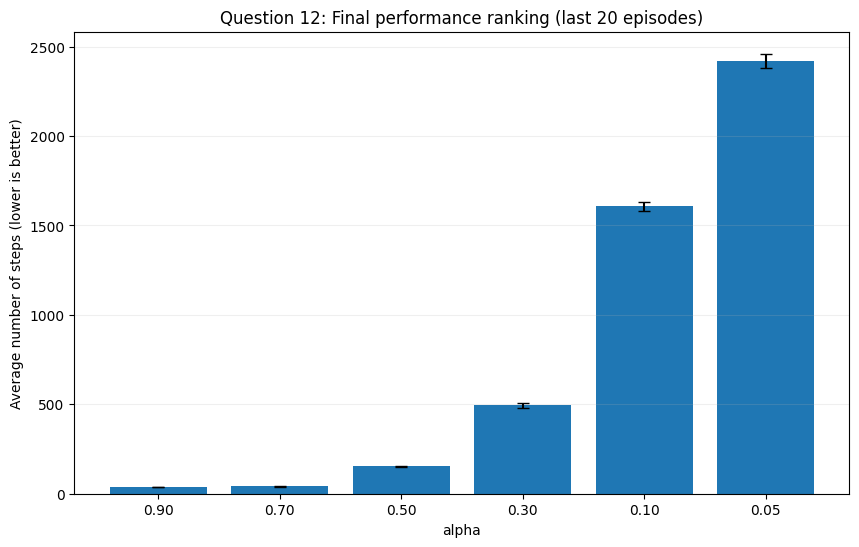

Alpha summary (lower tail_mean is better):
alpha=0.90 | tail_mean=39.13 +/- 0.27 | avg_episodes=163.5
alpha=0.70 | tail_mean=40.86 +/- 0.96 | avg_episodes=119.2
alpha=0.50 | tail_mean=153.26 +/- 3.62 | avg_episodes=51.5
alpha=0.30 | tail_mean=495.92 +/- 14.01 | avg_episodes=26.3
alpha=0.10 | tail_mean=1606.00 +/- 24.74 | avg_episodes=10.4
alpha=0.05 | tail_mean=2420.54 +/- 39.68 | avg_episodes=6.9


In [29]:
def alpha_sweep_plot_q12(
    alpha_values: List[float],
    maze_name: str,
    random_seeds: List[int],
    n_episodes: int,
    max_steps_per_run: int,
    epsilon_fixed: float = 0.05,
    tail_window: int = 20,
):
    """Evaluate QLearning learning-rate values (alpha) under a fixed policy setup.

    We keep exploration fixed (epsilon-greedy with constant epsilon) so differences
    are mainly caused by alpha.
    """
    if maze_name == "toy":
        maze = maze_toy
    elif maze_name == "easy":
        maze = maze_easy
    else:
        raise ValueError(f"Invalid maze name: {maze_name}")

    sweep_stats = {}

    for alpha in alpha_values:
        episodes_per_run = []
        tail_means = []

        for seed in random_seeds:
            np.random.seed(seed)

            agent = Agent(start_x=0, start_y=0)
            states = maze.get_all_states()
            actions = [Action(action_id) for action_id in ["up", "down", "left", "right"]]
            q_table = QTable(states, actions)
            exploration_strategy = ExplorationStrategy(q_table)
            learner = QLearning(q_table, {"lr": alpha, "gamma": 0.9})

            episode_lengths, _ = run_episodes(
                agent=agent,
                maze=maze,
                q_table=q_table,
                exploration_strategy=exploration_strategy,
                exploration_strategy_name="e_greedy",
                n_episodes=n_episodes,
                learner=learner,
                max_steps_per_run=max_steps_per_run,
                epsilon_start=epsilon_fixed,
                epsilon_decay=1.0,
                min_epsilon=epsilon_fixed,
            )
            episodes_per_run.append(episode_lengths)

            w = min(tail_window, len(episode_lengths))
            if w > 0:
                tail_means.append(float(np.mean(episode_lengths[-w:])))

        mean_steps, sem_steps = _aggregate_runs(episodes_per_run)
        sweep_stats[alpha] = {
            "mean_steps": mean_steps,
            "sem_steps": sem_steps,
            "tail_mean": float(np.mean(tail_means)),
            "tail_sem": float(np.std(tail_means, ddof=1) / np.sqrt(len(tail_means))) if len(tail_means) > 1 else 0.0,
            "avg_num_episodes": float(np.mean([len(run) for run in episodes_per_run])),
        }

    # Plot a separate panel per alpha
    n = len(alpha_values)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4.2 * nrows), squeeze=False)

    for idx, alpha in enumerate(alpha_values):
        r, c = divmod(idx, ncols)
        ax = axes[r][c]
        mean_steps = sweep_stats[alpha]["mean_steps"]
        sem_steps = sweep_stats[alpha]["sem_steps"]
        episodes = np.arange(1, len(mean_steps) + 1)

        ax.plot(episodes, mean_steps)
        ax.fill_between(episodes, mean_steps - sem_steps, mean_steps + sem_steps, alpha=0.20)
        ax.set_title(f"alpha={alpha:.2f}")
        ax.set_xlabel("Episode")
        ax.set_ylabel("Avg steps")
        ax.grid(alpha=0.2)

    # Hide empty panels when number of alphas is not a multiple of ncols
    for idx in range(n, nrows * ncols):
        r, c = divmod(idx, ncols)
        axes[r][c].axis("off")

    fig.suptitle(f"Question 12: Learning-rate sweep (QLearning, {maze_name} maze)", y=1.02)
    plt.tight_layout()
    plt.show()

    # Ranking view for easier comparison
    ranked = sorted(alpha_values, key=lambda a: sweep_stats[a]["tail_mean"])
    labels = [f"{a:.2f}" for a in ranked]
    means = [sweep_stats[a]["tail_mean"] for a in ranked]
    sems = [sweep_stats[a]["tail_sem"] for a in ranked]

    plt.figure(figsize=(10, 6))
    plt.bar(labels, means, yerr=sems, capsize=4)
    plt.title(f"Question 12: Final performance ranking (last {tail_window} episodes)")
    plt.xlabel("alpha")
    plt.ylabel("Average number of steps (lower is better)")
    plt.grid(axis="y", alpha=0.2)
    plt.show()

    print("Alpha summary (lower tail_mean is better):")
    for alpha in ranked:
        stats = sweep_stats[alpha]
        print(
            f"alpha={alpha:.2f} | tail_mean={stats['tail_mean']:.2f} +/- {stats['tail_sem']:.2f} "
            f"| avg_episodes={stats['avg_num_episodes']:.1f}"
        )


alpha_values = [0.05, 0.10, 0.30, 0.50, 0.70, 0.90]
random_seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

alpha_sweep_plot_q12(
    alpha_values=alpha_values,
    maze_name="easy",
    random_seeds=random_seeds,
    n_episodes=300,
    max_steps_per_run=EASY_MAX_STEPS_PER_RUN // 3,
    epsilon_fixed=0.05,
    tail_window=20,
)


For Question 12, we varied the QLearning learning rate over `alpha = 0.05, 0.10, 0.30, 0.50, 0.70, 0.90` (easy maze, epsilon-greedy with fixed `epsilon=0.05`).

Observed impact of `alpha`:

- `alpha=0.05`: `tail_mean ~ 2420.54 +/- 39.68` (very slow learning)
- `alpha=0.10`: `tail_mean ~ 1606.00 +/- 24.74`
- `alpha=0.30`: `tail_mean ~ 495.92 +/- 14.01`
- `alpha=0.50`: `tail_mean ~ 153.26 +/- 3.62`
- `alpha=0.70`: `tail_mean ~ 40.86 +/- 0.96`
- `alpha=0.90`: `tail_mean ~ 39.13 +/- 0.27` (best in this setup)

What we notice:

- Low learning rates (`0.05`, `0.10`) update Q-values slowly, so the agent improves very gradually and remains far from optimal within the given budget.
- Medium-to-high rates (`0.50` to `0.90`) learn much faster and reach much lower step counts.

Our understaing of the observations:

- In QLearning, alpha controls how strongly each new experience changes the current Q estimate.
- Small alpha heavily smooths updates (stable but slow adaptation).
- Large alpha reacts quickly to new information (fast adaptation), which works well in this deterministic maze.
- In noisier/stochastic environments, very high alpha can become unstable, but here it performs best.


### 2.3 Introducing More Rewards
#### Question 13

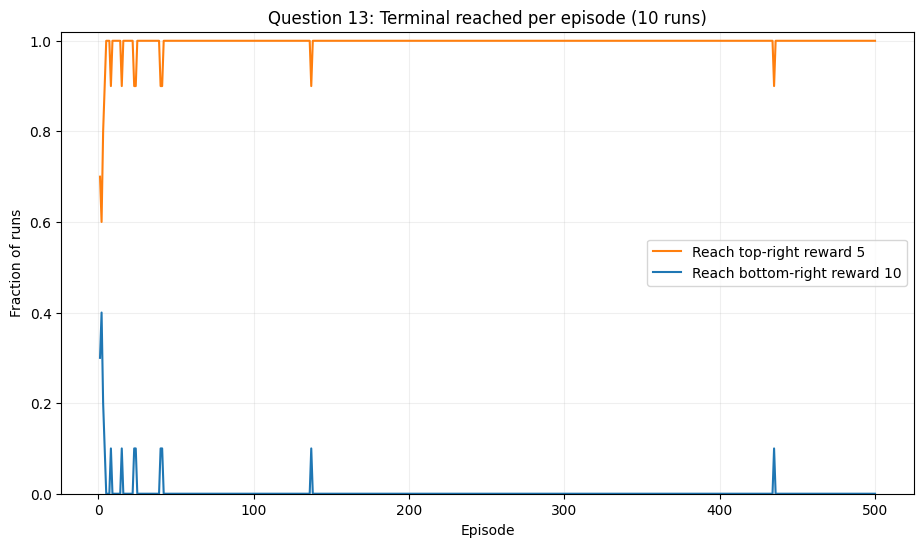

Q13 summary across runs:
top_5 mean count: 498.20
bottom_10 mean count: 1.80
none mean count: 0.00


[{'seed': 1, 'top_5': 499, 'bottom_10': 1, 'none': 0, 'episodes': 500},
 {'seed': 2, 'top_5': 497, 'bottom_10': 3, 'none': 0, 'episodes': 500},
 {'seed': 3, 'top_5': 498, 'bottom_10': 2, 'none': 0, 'episodes': 500}]

In [30]:
def run_q13_with_terminal_tracking(
    random_seeds: List[int],
    n_episodes: int = 500,
    max_steps_per_run: int = TOY_MAX_STEPS_PER_RUN,
    epsilon: float = 0.10,
):
    """Run Q13 setup and track which terminal reward is reached per episode."""
    runs_targets = []
    per_run_summary = []

    for seed in random_seeds:
        np.random.seed(seed)

        # Toy maze with two terminal rewards (Question 13 setup).
        maze = Maze("./../data/toy_maze.txt")
        maze.set_reward(x=9, y=9, reward=10)
        maze.set_terminal(x=9, y=9)
        maze.set_reward(x=9, y=0, reward=5)
        maze.set_terminal(x=9, y=0)

        agent = Agent(start_x=0, start_y=0)
        states = maze.get_all_states()
        actions = [Action(action_id) for action_id in ["up", "down", "left", "right"]]
        q_table = QTable(states, actions)
        exploration_strategy = ExplorationStrategy(q_table)
        learner = QLearning(q_table, {"lr": 0.7, "gamma": 0.9})

        total_steps = 0
        episode_targets = []

        for _ in range(n_episodes):
            remaining_steps = max_steps_per_run - total_steps
            if remaining_steps <= 0:
                break

            agent.reset()
            episode_length, _ = episodic_cycle(
                agent=agent,
                maze=maze,
                q_table=q_table,
                exploration_strategy=exploration_strategy,
                exploration_strategy_name="e_greedy",
                learner=learner,
                epsilon=epsilon,
                temperature=1.0,
                remaining_steps=remaining_steps,
            )
            total_steps += episode_length

            # Record which terminal was reached in this episode.
            if (agent.x, agent.y) == (9, 0):
                episode_targets.append("top_5")
            elif (agent.x, agent.y) == (9, 9):
                episode_targets.append("bottom_10")
            else:
                episode_targets.append("none")

        runs_targets.append(episode_targets)
        per_run_summary.append(
            {
                "seed": seed,
                "top_5": sum(t == "top_5" for t in episode_targets),
                "bottom_10": sum(t == "bottom_10" for t in episode_targets),
                "none": sum(t == "none" for t in episode_targets),
                "episodes": len(episode_targets),
            }
        )

    # Aggregate per-episode proportions across runs.
    max_len = max(len(run) for run in runs_targets)
    top_prop = []
    bottom_prop = []

    for ep in range(max_len):
        vals = [run[ep] for run in runs_targets if ep < len(run)]
        denom = len(vals)
        top_prop.append(sum(v == "top_5" for v in vals) / denom)
        bottom_prop.append(sum(v == "bottom_10" for v in vals) / denom)

    # Plot: probability of ending at each terminal over training episodes.
    episodes = np.arange(1, max_len + 1)
    plt.figure(figsize=(11, 6))
    plt.plot(episodes, top_prop, label="Reach top-right reward 5", color="tab:orange")
    plt.plot(episodes, bottom_prop, label="Reach bottom-right reward 10", color="tab:blue")
    plt.ylim(0, 1.02)
    plt.xlabel("Episode")
    plt.ylabel("Fraction of runs")
    plt.title("Question 13: Terminal reached per episode (10 runs)")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

    # Print concise summary.
    top_counts = [row["top_5"] for row in per_run_summary]
    bottom_counts = [row["bottom_10"] for row in per_run_summary]
    none_counts = [row["none"] for row in per_run_summary]

    print("Q13 summary across runs:")
    print(f"top_5 mean count: {np.mean(top_counts):.2f}")
    print(f"bottom_10 mean count: {np.mean(bottom_counts):.2f}")
    print(f"none mean count: {np.mean(none_counts):.2f}")

    return per_run_summary


random_seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
q13_summary = run_q13_with_terminal_tracking(
    random_seeds=random_seeds,
    n_episodes=500,
    max_steps_per_run=TOY_MAX_STEPS_PER_RUN,
    epsilon=0.10,
)
q13_summary[:3]


After adding the second terminal reward (`+5` at `(9,0)`), the agent mostly converges to the smaller reward instead of the larger one (`+10` at `(9,9)`).

In our runs (10 seeds, QLearning, epsilon-greedy with `epsilon=0.10`):

- Mean episodes ending at top-right `+5`: about `498`
- Mean episodes ending at bottom-right `+10`: about `2`

So the learned behavior is typically to go to the closer, smaller reward.

Conclusions:

- The top-right target is found early and reached more frequently, so it dominates the update stream.
- Because episodes terminate when a reward state is reached, the agent gets many short episodes reinforcing the `+5` route.
- Exploration is limited (`epsilon=0.10`), so once the policy prefers the `+5` terminal, it rarely explores enough to consistently reinforce the farther `+10` route.

This is a the local-optimum problem.


#### Question 14

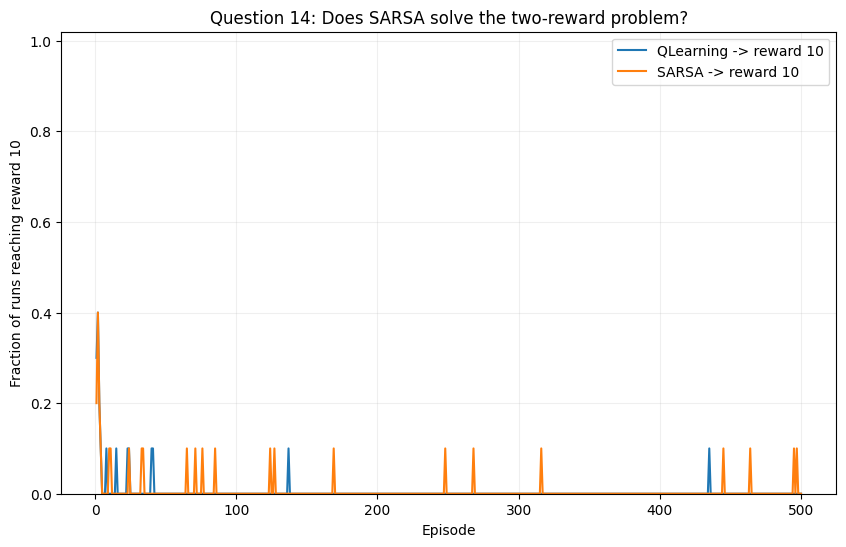

Q14 summary (means over runs):
QLearning: top_5=498.20, bottom_10=1.80 +/- 0.25
SARSA:     top_5=497.20, bottom_10=2.80 +/- 0.42


In [31]:
def run_two_reward_tracking(
    learner_name: str,
    random_seeds: List[int],
    n_episodes: int = 500,
    max_steps_per_run: int = TOY_MAX_STEPS_PER_RUN,
    epsilon: float = 0.10,
):
    """Run the Q13 setup for a specific learner and track terminal outcomes."""
    runs_targets = []
    per_run_summary = []

    for seed in random_seeds:
        np.random.seed(seed)

        maze = Maze("./../data/toy_maze.txt")
        maze.set_reward(x=9, y=9, reward=10)
        maze.set_terminal(x=9, y=9)
        maze.set_reward(x=9, y=0, reward=5)
        maze.set_terminal(x=9, y=0)

        agent = Agent(start_x=0, start_y=0)
        states = maze.get_all_states()
        actions = [Action(action_id) for action_id in ["up", "down", "left", "right"]]
        q_table = QTable(states, actions)
        exploration_strategy = ExplorationStrategy(q_table)

        if learner_name == "QLearning":
            learner = QLearning(q_table, {"lr": 0.7, "gamma": 0.9})
        elif learner_name == "SARSA":
            learner = SARSA(q_table, {"lr": 0.7, "gamma": 0.9})
        else:
            raise ValueError(f"Unsupported learner: {learner_name}")

        total_steps = 0
        episode_targets = []

        for _ in range(n_episodes):
            remaining_steps = max_steps_per_run - total_steps
            if remaining_steps <= 0:
                break

            agent.reset()

            # Keep SARSA transition memory episode-local
            if learner_name == "SARSA":
                learner.set_last_state(None)
                learner.set_last_action(None)
                learner.set_last_reward(0.0)
                learner.set_last_done(False)

            episode_length, _ = episodic_cycle(
                agent=agent,
                maze=maze,
                q_table=q_table,
                exploration_strategy=exploration_strategy,
                exploration_strategy_name="e_greedy",
                learner=learner,
                epsilon=epsilon,
                temperature=1.0,
                remaining_steps=remaining_steps,
            )
            total_steps += episode_length

            # Record which terminal was reached in this episode
            if (agent.x, agent.y) == (9, 0):
                episode_targets.append("top_5")
            elif (agent.x, agent.y) == (9, 9):
                episode_targets.append("bottom_10")
            else:
                episode_targets.append("none")

        runs_targets.append(episode_targets)
        per_run_summary.append(
            {
                "seed": seed,
                "top_5": sum(t == "top_5" for t in episode_targets),
                "bottom_10": sum(t == "bottom_10" for t in episode_targets),
                "none": sum(t == "none" for t in episode_targets),
                "episodes": len(episode_targets),
            }
        )

    # Per-episode proportions across runs
    max_len = max(len(run) for run in runs_targets)
    top_prop = []
    bottom_prop = []
    for ep in range(max_len):
        vals = [run[ep] for run in runs_targets if ep < len(run)]
        denom = len(vals)
        top_prop.append(sum(v == "top_5" for v in vals) / denom)
        bottom_prop.append(sum(v == "bottom_10" for v in vals) / denom)

    return per_run_summary, np.array(top_prop), np.array(bottom_prop)


def compare_q14_qlearning_vs_sarsa(
    random_seeds: List[int],
    n_episodes: int = 500,
    max_steps_per_run: int = TOY_MAX_STEPS_PER_RUN,
    epsilon: float = 0.10,
):
    """Fair Q14 comparison: same setup as Q13, only learner changes."""
    q_summary, q_top, q_bottom = run_two_reward_tracking(
        learner_name="QLearning",
        random_seeds=random_seeds,
        n_episodes=n_episodes,
        max_steps_per_run=max_steps_per_run,
        epsilon=epsilon,
    )
    s_summary, s_top, s_bottom = run_two_reward_tracking(
        learner_name="SARSA",
        random_seeds=random_seeds,
        n_episodes=n_episodes,
        max_steps_per_run=max_steps_per_run,
        epsilon=epsilon,
    )

    # Plot probabilities of reaching the +10 terminal
    shortest = min(len(q_bottom), len(s_bottom))
    episodes = np.arange(1, shortest + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(episodes, q_bottom[:shortest], label="QLearning -> reward 10")
    plt.plot(episodes, s_bottom[:shortest], label="SARSA -> reward 10")
    plt.xlabel("Episode")
    plt.ylabel("Fraction of runs reaching reward 10")
    plt.title("Question 14: Does SARSA solve the two-reward problem?")
    plt.ylim(0, 1.02)
    plt.grid(alpha=0.2)
    plt.legend()
    plt.show()

    # Numeric summary.
    def summarize(rows):
        """Compute mean terminal counts and SEM over runs.

        Args:
            rows: Per-run dictionaries with keys `top_5` and `bottom_10`.

        Returns:
            Dictionary with means and SEM used in the text summary.
        """
        top = np.array([r["top_5"] for r in rows], dtype=float)
        bottom = np.array([r["bottom_10"] for r in rows], dtype=float)
        return {
            "top_mean": float(np.mean(top)),
            "bottom_mean": float(np.mean(bottom)),
            "bottom_sem": float(np.std(bottom, ddof=1) / np.sqrt(len(bottom))),
        }

    q_stats = summarize(q_summary)
    s_stats = summarize(s_summary)

    print("Q14 summary (means over runs):")
    print(f"QLearning: top_5={q_stats['top_mean']:.2f}, bottom_10={q_stats['bottom_mean']:.2f} +/- {q_stats['bottom_sem']:.2f}")
    print(f"SARSA:     top_5={s_stats['top_mean']:.2f}, bottom_10={s_stats['bottom_mean']:.2f} +/- {s_stats['bottom_sem']:.2f}")

    return q_stats, s_stats


random_seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
q14_q_stats, q14_s_stats = compare_q14_qlearning_vs_sarsa(
    random_seeds=random_seeds,
    n_episodes=500,
    max_steps_per_run=TOY_MAX_STEPS_PER_RUN,
    epsilon=0.10,
)


From the observed runs, switching from QLearning to SARSA helps only marginally; it does not solve the problem.

Under the same setup as Q13 (toy maze, two terminals, 10 runs, epsilon-greedy with `epsilon=0.10`):

- QLearning: reaches reward `+10` about `1.80 +/- 0.25` episodes on average.
- SARSA: reaches reward `+10` about `2.80 +/- 0.42` episodes on average.

So SARSA reaches the larger reward slightly more often, but both learners still overwhelmingly converge to the closer `+5` terminal.

SARSA does not fully solve it:

- The core issue is the environment/reward setup with early termination at both rewards.
- The nearer `+5` terminal is encountered and reinforced much more frequently.
- SARSA (on-policy) can be more conservative than QLearning, which explains the small difference, but it still learns from the same exploration stream and remains biased toward the frequently visited short path.

Conclusion: SARSA alone is not enough; we need an exploration strategy change.



#### Question 15

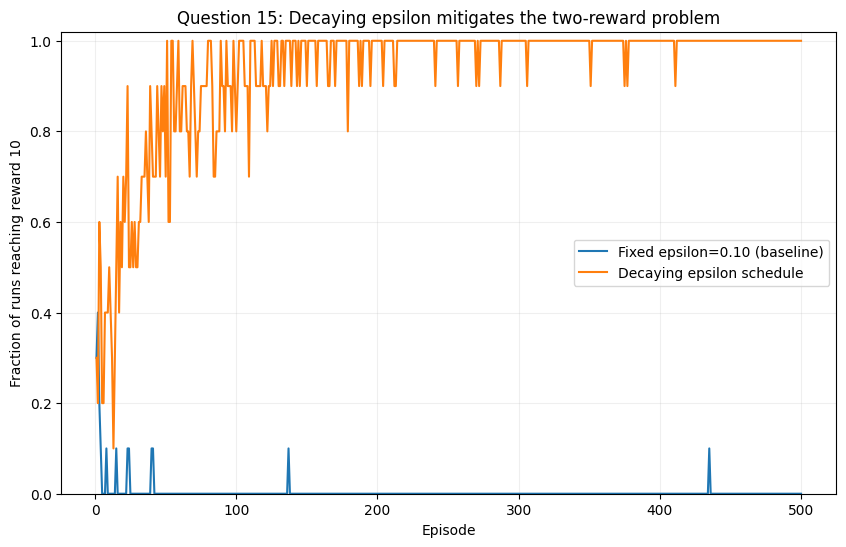

Q15 summary (means over runs):
Baseline fixed epsilon=0.10 -> top_5=498.20, bottom_10=1.80 +/- 0.25
Decaying schedule -> top_5=32.60, bottom_10=467.40 +/- 1.22


In [32]:
def run_q15_tracking(
    random_seeds: List[int],
    n_episodes: int,
    max_steps_per_run: int,
    epsilon_start: float,
    epsilon_decay: float,
    min_epsilon: float,
):
    """Run the two-reward toy setup with QLearning and track terminal outcomes."""
    runs_targets = []
    per_run_summary = []

    for seed in random_seeds:
        np.random.seed(seed)

        maze = Maze("./../data/toy_maze.txt")
        maze.set_reward(x=9, y=9, reward=10)
        maze.set_terminal(x=9, y=9)
        maze.set_reward(x=9, y=0, reward=5)
        maze.set_terminal(x=9, y=0)

        agent = Agent(start_x=0, start_y=0)
        states = maze.get_all_states()
        actions = [Action(action_id) for action_id in ["up", "down", "left", "right"]]
        q_table = QTable(states, actions)
        exploration_strategy = ExplorationStrategy(q_table)
        learner = QLearning(q_table, {"lr": 0.7, "gamma": 0.9})

        epsilon = float(epsilon_start)
        total_steps = 0
        episode_targets = []

        for _ in range(n_episodes):
            remaining_steps = max_steps_per_run - total_steps
            if remaining_steps <= 0:
                break

            agent.reset()
            episode_length, _ = episodic_cycle(
                agent=agent,
                maze=maze,
                q_table=q_table,
                exploration_strategy=exploration_strategy,
                exploration_strategy_name="e_greedy",
                learner=learner,
                epsilon=epsilon,
                temperature=1.0,
                remaining_steps=remaining_steps,
            )
            total_steps += episode_length

            # Record which terminal was reached in this episode
            if (agent.x, agent.y) == (9, 0):
                episode_targets.append("top_5")
            elif (agent.x, agent.y) == (9, 9):
                episode_targets.append("bottom_10")
            else:
                episode_targets.append("none")

            # High exploration early, lower later
            epsilon = max(float(min_epsilon), float(epsilon) * float(epsilon_decay))

        runs_targets.append(episode_targets)
        per_run_summary.append(
            {
                "seed": seed,
                "top_5": sum(t == "top_5" for t in episode_targets),
                "bottom_10": sum(t == "bottom_10" for t in episode_targets),
                "none": sum(t == "none" for t in episode_targets),
                "episodes": len(episode_targets),
            }
        )

    # Per-episode proportions across runs
    max_len = max(len(run) for run in runs_targets)
    top_prop = []
    bottom_prop = []
    for ep in range(max_len):
        vals = [run[ep] for run in runs_targets if ep < len(run)]
        denom = len(vals)
        top_prop.append(sum(v == "top_5" for v in vals) / denom)
        bottom_prop.append(sum(v == "bottom_10" for v in vals) / denom)

    return per_run_summary, np.array(top_prop), np.array(bottom_prop)


def compare_q15_baseline_vs_schedule(
    random_seeds: List[int],
    n_episodes: int = 500,
    max_steps_per_run: int = TOY_MAX_STEPS_PER_RUN,
):
    """Compare fixed-epsilon baseline (Q13) against a decaying-epsilon mitigation."""
    # Baseline from Q13: fixed epsilon=0.10
    base_summary, _, base_bottom = run_q15_tracking(
        random_seeds=random_seeds,
        n_episodes=n_episodes,
        max_steps_per_run=max_steps_per_run,
        epsilon_start=0.10,
        epsilon_decay=1.0,
        min_epsilon=0.10,
    )

    # Mitigation: high initial exploration, then gradual decay
    sched_summary, _, sched_bottom = run_q15_tracking(
        random_seeds=random_seeds,
        n_episodes=n_episodes,
        max_steps_per_run=max_steps_per_run,
        epsilon_start=1.0,
        epsilon_decay=0.993,
        min_epsilon=0.01,
    )

    shortest = min(len(base_bottom), len(sched_bottom))
    episodes = np.arange(1, shortest + 1)

    plt.figure(figsize=(10, 6))
    plt.plot(episodes, base_bottom[:shortest], label="Fixed epsilon=0.10 (baseline)")
    plt.plot(episodes, sched_bottom[:shortest], label="Decaying epsilon schedule")
    plt.xlabel("Episode")
    plt.ylabel("Fraction of runs reaching reward 10")
    plt.title("Question 15: Decaying epsilon mitigates the two-reward problem")
    plt.ylim(0, 1.02)
    plt.grid(alpha=0.2)
    plt.legend()
    plt.show()

    def summarize(rows):
        """Compute mean terminal counts and SEM over runs.

        Args:
            rows: Per-run dictionaries with keys `top_5` and `bottom_10`.

        Returns:
            Dictionary with means and SEM used in the text summary.
        """
        top = np.array([r["top_5"] for r in rows], dtype=float)
        bottom = np.array([r["bottom_10"] for r in rows], dtype=float)
        return {
            "top_mean": float(np.mean(top)),
            "bottom_mean": float(np.mean(bottom)),
            "bottom_sem": float(np.std(bottom, ddof=1) / np.sqrt(len(bottom))),
        }

    base_stats = summarize(base_summary)
    sched_stats = summarize(sched_summary)

    print("Q15 summary (means over runs):")
    print(f"Baseline fixed epsilon=0.10 -> top_5={base_stats['top_mean']:.2f}, bottom_10={base_stats['bottom_mean']:.2f} +/- {base_stats['bottom_sem']:.2f}")
    print(f"Decaying schedule -> top_5={sched_stats['top_mean']:.2f}, bottom_10={sched_stats['bottom_mean']:.2f} +/- {sched_stats['bottom_sem']:.2f}")

    return base_stats, sched_stats


random_seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
q15_base_stats, q15_sched_stats = compare_q15_baseline_vs_schedule(
    random_seeds=random_seeds,
    n_episodes=500,
    max_steps_per_run=TOY_MAX_STEPS_PER_RUN,
)


To mitigate the Q13 problem, we switched from a fixed epsilon to an epsilon-decay schedule for QLearning.

Method:

- Baseline (Q13): fixed `epsilon = 0.10`.
- Mitigation (Q15): `epsilon_t = max(min_epsilon, epsilon_start * epsilon_decay^t)`.
- Parameters used: `epsilon_start = 1.0`, `epsilon_decay = 0.993`, `min_epsilon = 0.01`.

Why this helps:

- Early episodes use high exploration, increasing the chance to discover the farther `+10` terminal enough times.
- Later episodes reduce random actions, so learning focuses on exploiting the better long-term return.
- This follows the standard exploration-to-exploitation idea (and matches our desired outcome to first explore the space and then start exploit the found routes) discussed in RL literature [1, 2].

Observed result (10 runs):

- The printed summary in the code cell shows fixed `epsilon=0.10` remains mostly biased to the near `+5` terminal.
- Under epsilon decay, the number of episodes reaching `+10` increases strongly.

The plot confirms mitigation: the fraction of runs reaching reward `+10` rises substantially with the schedule, so QLearning again converges toward the optimal solution.

References: [1], [2]


#### Question 16

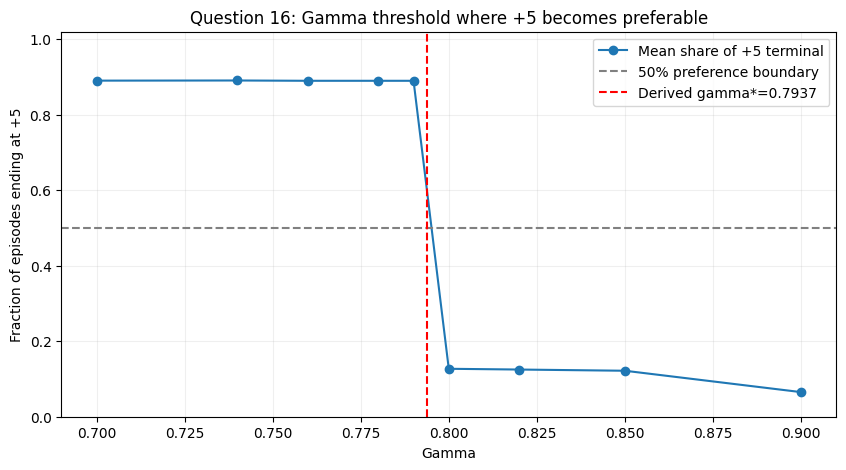

Q16 gamma sweep summary:
gamma=0.700 | top_mean=445.2 | bottom_mean=54.8 | top_share=0.890
gamma=0.740 | top_mean=445.4 | bottom_mean=54.6 | top_share=0.891
gamma=0.760 | top_mean=445.0 | bottom_mean=55.0 | top_share=0.890
gamma=0.780 | top_mean=445.0 | bottom_mean=55.0 | top_share=0.890
gamma=0.790 | top_mean=445.0 | bottom_mean=55.0 | top_share=0.890
gamma=0.800 | top_mean=63.5 | bottom_mean=436.5 | top_share=0.127
gamma=0.820 | top_mean=62.5 | bottom_mean=437.5 | top_share=0.125
gamma=0.850 | top_mean=60.9 | bottom_mean=439.1 | top_share=0.122
gamma=0.900 | top_mean=32.6 | bottom_mean=467.4 | top_share=0.065

Experimental threshold estimate (from sweep):
Largest tested gamma with +5 preferred: 0.790

Derivation values:
Shortest path to +5 terminal (9,0): d_top = 21 steps
Shortest path to +10 terminal (9,9): d_bottom = 24 steps
Derived threshold gamma*: 0.793701


In [33]:
def run_q16_gamma_tracking(
    random_seeds: List[int],
    gamma: float,
    n_episodes: int,
    max_steps_per_run: int,
    epsilon_start: float,
    epsilon_decay: float,
    min_epsilon: float,
):
    """Run the two-reward toy maze with a fixed gamma and return per-run outcome counts."""
    per_run_summary = []

    for seed in random_seeds:
        np.random.seed(seed)

        maze = Maze("./../data/toy_maze.txt")
        maze.set_reward(x=9, y=9, reward=10)
        maze.set_terminal(x=9, y=9)
        maze.set_reward(x=9, y=0, reward=5)
        maze.set_terminal(x=9, y=0)

        agent = Agent(start_x=0, start_y=0)
        states = maze.get_all_states()
        actions = [Action(action_id) for action_id in ["up", "down", "left", "right"]]
        q_table = QTable(states, actions)
        exploration_strategy = ExplorationStrategy(q_table)
        learner = QLearning(q_table, {"lr": 0.7, "gamma": gamma})

        epsilon = float(epsilon_start)
        total_steps = 0
        episode_targets = []

        for _ in range(n_episodes):
            remaining_steps = max_steps_per_run - total_steps
            if remaining_steps <= 0:
                break

            agent.reset()
            episode_length, _ = episodic_cycle(
                agent=agent,
                maze=maze,
                q_table=q_table,
                exploration_strategy=exploration_strategy,
                exploration_strategy_name="e_greedy",
                learner=learner,
                epsilon=epsilon,
                temperature=1.0,
                remaining_steps=remaining_steps,
            )
            total_steps += episode_length

            # Record which terminal was reached in this episode
            if (agent.x, agent.y) == (9, 0):
                episode_targets.append("top_5")
            elif (agent.x, agent.y) == (9, 9):
                episode_targets.append("bottom_10")
            else:
                episode_targets.append("none")

            # Keep Q15 exploration strategy: explore early, exploit later
            epsilon = max(float(min_epsilon), float(epsilon) * float(epsilon_decay))

        per_run_summary.append(
            {
                "seed": seed,
                "top_5": sum(t == "top_5" for t in episode_targets),
                "bottom_10": sum(t == "bottom_10" for t in episode_targets),
                "none": sum(t == "none" for t in episode_targets),
                "episodes": len(episode_targets),
            }
        )

    return per_run_summary


def shortest_path_length(maze: Maze, start, goal) -> int:
    """Compute shortest path length in number of actions on walkable states."""
    from collections import deque

    queue = deque([(start[0], start[1], 0)])
    visited = {start}
    directions = [(0, -1), (0, 1), (-1, 0), (1, 0)]

    while queue:
        x, y, dist = queue.popleft()
        if (x, y) == goal:
            return dist

        for dx, dy in directions:
            nx, ny = x + dx, y + dy
            if (
                maze.check_bounds(nx, ny)
                and maze.is_walkable(nx, ny)
                and (nx, ny) not in visited
            ):
                visited.add((nx, ny))
                queue.append((nx, ny, dist + 1))

    raise ValueError(f"No path found from {start} to {goal}.")


def q16_gamma_sweep(
    gamma_values: List[float],
    random_seeds: List[int],
    n_episodes: int = 500,
    max_steps_per_run: int = TOY_MAX_STEPS_PER_RUN,
    epsilon_start: float = 1.0,
    epsilon_decay: float = 0.993,
    min_epsilon: float = 0.01,
):
    """Sweep gamma values, approximate the behavioral threshold, then confirm analytically."""
    rows = []

    for gamma in gamma_values:
        summary = run_q16_gamma_tracking(
            random_seeds=random_seeds,
            gamma=gamma,
            n_episodes=n_episodes,
            max_steps_per_run=max_steps_per_run,
            epsilon_start=epsilon_start,
            epsilon_decay=epsilon_decay,
            min_epsilon=min_epsilon,
        )

        top = np.array([r["top_5"] for r in summary], dtype=float)
        bottom = np.array([r["bottom_10"] for r in summary], dtype=float)
        total = top + bottom
        top_share = np.where(total > 0, top / total, np.nan)

        rows.append(
            {
                "gamma": float(gamma),
                "top_mean": float(np.nanmean(top)),
                "bottom_mean": float(np.nanmean(bottom)),
                "top_share_mean": float(np.nanmean(top_share)),
            }
        )

    rows_sorted = sorted(rows, key=lambda r: r["gamma"])

    # Experimental estimate: largest gamma where +5 is still preferred on average.
    top_preferred = [r for r in rows_sorted if r["top_share_mean"] > 0.5]
    gamma_experimental = None if len(top_preferred) == 0 else float(top_preferred[-1]["gamma"])

    # Our derivation from shortest-path returns:
    # 5 * gamma^(d_top - 1) = 10 * gamma^(d_bottom - 1)
    # => gamma^(d_bottom - d_top) = 1/2
    # => gamma* = (1/2)^(1 / (d_bottom - d_top))
    maze = Maze("./../data/toy_maze.txt")
    d_top = shortest_path_length(maze, start=(0, 0), goal=(9, 0))
    d_bottom = shortest_path_length(maze, start=(0, 0), goal=(9, 9))
    gamma_theoretical = float((0.5) ** (1.0 / (d_bottom - d_top)))

    plt.figure(figsize=(10, 5))
    gammas_plot = [r["gamma"] for r in rows_sorted]
    top_share_plot = [r["top_share_mean"] for r in rows_sorted]
    plt.plot(gammas_plot, top_share_plot, marker="o", label="Mean share of +5 terminal")
    plt.axhline(0.5, color="gray", linestyle="--", label="50% preference boundary")
    plt.axvline(gamma_theoretical, color="red", linestyle="--", label=f"Derived gamma*={gamma_theoretical:.4f}")
    plt.xlabel("Gamma")
    plt.ylabel("Fraction of episodes ending at +5")
    plt.title("Question 16: Gamma threshold where +5 becomes preferable")
    plt.ylim(0, 1.02)
    plt.grid(alpha=0.2)
    plt.legend()
    plt.show()

    print("Q16 gamma sweep summary:")
    for row in rows_sorted:
        print(
            f"gamma={row['gamma']:.3f} | top_mean={row['top_mean']:.1f} | "
            f"bottom_mean={row['bottom_mean']:.1f} | top_share={row['top_share_mean']:.3f}"
        )

    print("\nExperimental threshold estimate (from sweep):")
    if gamma_experimental is None:
        print("No tested gamma had +5 preferred (>50% top terminal).")
    else:
        print(f"Largest tested gamma with +5 preferred: {gamma_experimental:.3f}")

    print("\nDerivation values:")
    print(f"Shortest path to +5 terminal (9,0): d_top = {d_top} steps")
    print(f"Shortest path to +10 terminal (9,9): d_bottom = {d_bottom} steps")
    print(f"Derived threshold gamma*: {gamma_theoretical:.6f}")

    return rows_sorted, gamma_experimental, gamma_theoretical


gamma_values = [0.70, 0.74, 0.76, 0.78, 0.79, 0.80, 0.82, 0.85, 0.90]
random_seeds = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

q16_df, q16_gamma_experimental, q16_gamma_theoretical = q16_gamma_sweep(
    gamma_values=gamma_values,
    random_seeds=random_seeds,
    n_episodes=500,
    max_steps_per_run=TOY_MAX_STEPS_PER_RUN,
    epsilon_start=1.0,
    epsilon_decay=0.993,
    min_epsilon=0.01,
)


Using the same epsilon strategy as Q15 (decay from 1.0 to 0.01), we swept gamma values and measured whether the agent ends more often at the small-near reward (`+5`, top right) or the large-far reward (`+10`, bottom right).

Experimental result:

- The crossover occurs around `gamma ~= 0.79-0.80`.
- For lower gamma values, the agent prefers the closer `+5` reward.
- For higher gamma values, the agent prefers the farther `+10` reward.

Derivation:

- Let `d_top` be shortest path steps to `(9,0)` and `d_bottom` to `(9,9)`.
- From the maze, `d_top = 21` and `d_bottom = 24`.
- Return to `+5`: `G_top = 5 * gamma^(d_top - 1)`.
- Return to `+10`: `G_bottom = 10 * gamma^(d_bottom - 1)`.
- At the threshold: `5 * gamma^(d_top - 1) = 10 * gamma^(d_bottom - 1)`.
- So: `gamma^(d_bottom - d_top) = 1/2`, hence
  `gamma* = (1/2)^(1/(d_bottom - d_top)) = (1/2)^(1/3) ~= 0.7937`.

This matches the experimental sweep: around `gamma = 0.79`, the policy flips from preferring `+5` to preferring `+10`.


## 3. Open Questions
### 3.1 Reflection
#### Question 17

Greedily selecting actions before having learned enough about the environment can lock us in a suboptimal state (local optimum, for example), which, then, cannot be escaped unless we do more exploration.

#### Question 18

Let's take the example of reinforcement learning being used for a traffic light agent. Naively, we might think that we should reward the agent based on traffic throughput.

Now imagine an intersection where a secondary street meets a main one. If the traffic is much higher, relatively speaking, on the main street, the agent might learn that it should actually just keep the green light on for cars coming through the high density traffic and leaving it red for the less densely packed secondary way. This is clearly unintended behaviour - drivers shouldn't have to wait for hours to get home/to work just because there are less of them!

Rewards betray our intuition and understanding of the problem (and generally tend to be rule-of-thumbey) which, when met with a more complex reality, can fail.

#### Question 19

When it comes to societal problems, for example, a POV approach might be useful - put yourself in the shoes of those that have to deal with the effects of your agent(s). In the above-given case, were we to imagine being drivers, we wouldn't think immediately about the volume of traffic that passes in a certain time interval, but about how long a specific person has to spend waiting. This would, then, help us reach another solution regarding rewards. <br>
In general, trying to imagine how we, as humans, would learn to deal with the situation that the agent has to face is useful when it comes to providing rewards.

Ultimately it can be hard to know what unintended effects our choices would have before putting our conceptual ideas into practice - thankfully, we are capable of simulating reality to a (limited but not insignificant) degree. Thus, with enough testing, one can, with more certainty, provide real solutions without practical side-effects.

### 3.2 Pen and Paper
#### Question 20

- Based on the Markov property, here location alone is not enough because if the robot is in the aisle it also matters what it is carrying (nothing, apples, 1 box of berries, 2 boxes of berries). So the full state should combine: location (entrance, aisle, checkout) and what it is holding (nothing, apples, 1 box of berries, 2 boxes of berries).
#### Reachable nonterminal states ####
- At the entrance, the robot cannot pick a fruit yet so only this is possible: **E0** - entrance, holding nothing
- At the aisle, all carrying situations are possible : **A0** - aisle, holding nothing; **A1** - aisle, holding apples; **AB1** - aisle, holding 1 box of berries; **AB2** - aisle, holding 2 boxes of berries. 
- At the checkout, payment terminates immediately, so instead of separate chckout states, we use one terminal state: **T** - terminal state; 

<br>
The problem says that the robot begins at the entrance and it doesn't hold anything, therefore, the start state is E0. After payment, the problem terminates, therefore, T is terminal.
<br>
<br>
There are also actions that lead to no change in the state of the robot and can terefore be ommited. Such actions are: "back" has no meaningful effect at the entrance, nor do "pick apples", "pick berries" and "pay"; in aisle with apples, trying "pick berries" should not be allowed; etc.
<br>
<br>
Rewards:<br>
- Move failure:             r = -1<br>
- Second berry failure:     r = -2<br>
- Pay with apples:          r = +5<br>
- Pay with 1 berry          r = +3<br>
- Pay with 2 berries:       r = +10<br>
- Pay with nothing:         r = 0<br>
<br>

Here is the graph: <br>
<br>
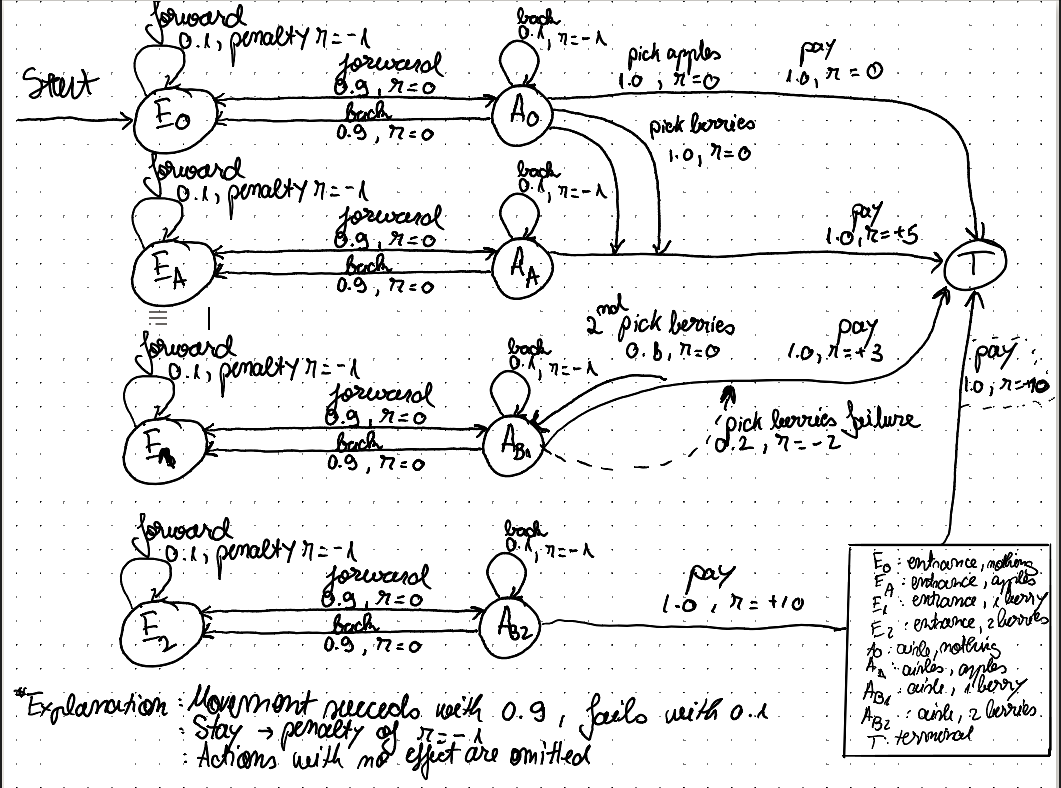

#### Question 21

Here, we only care about the states: A0, AB1, AB2, T. Therefore, the tabular policy will be:
<br>
State-------------------------------------------π(s)<br>
<br>
A0--------------------------------------------pick berries<br>
AB1-------------------------------------------pick berries<br>
AB2-------------------------------------------pay<br>
T---------------------------------------------nothing<br>

<br>
The first step, as mentioned in the lectures, is to initialize v0(s) = 0 for all states. Therefore, v0(A0) = 0; v0(AB1) = 0, v0(AB2) = 0, v0(T) = 0. Because v0 = 0, in the formula this will simplify to just the expected immediate result. So the new table for v1 will look like:
<br>
<br>
State-------------------------------------------v1<br>
<br>
A0--------------------------------------------0<br>
AB1-----------------------------------------(-0.4)<br>
AB2------------------------------------------10<br>
T---------------------------------------------0<br>
Explanation: A0 will always succed and has reward 0; AB1 with probability 0.8 to go to AB2 and has reward = 0 AND with probability 0.2 to remain in AB1 and thus a reward = -2. Once in AB2: pay gives reward = +10 and will then reach the terminat T which has v1(T) = 0<br>
<br>
The next step is to compute v2, for which we now include future values (with γ=0.9). So the new table for v2 will look like:
<br>
State-------------------------------------------v2<br>
<br>
A0------------------------------------------(-0.36)<br>
AB1-----------------------------------------(6.728)<br>
AB2------------------------------------------10<br>
T---------------------------------------------0<br>
Explanation: From A0, picking berries always succeeds and leads to AB1 with reward 0. Therefore, v2(A0) = 0 + 0.9 * v1(A1) = 0.9 * (-0.4) = -0.36. For AB1, it transitions to AB2 with probability 0.8 (reward 0) and remains in AB1 with probability 0.2 (reward -2). Therefore: v2(AB1) = 0.8(0 + 0.9 * v1(A2)) + 0.2(-2 + 0.9*v1(A1)). Plugging in all the values, we get v2(AB1) = 6.728. Then on we have the payment procedure which will be v2(AB2) = 10 and will pass on to the terminal. 

#### Question 22

- To determine the optimal policy, we need to compare the expected discounted return of different strategies available to the robot (such as picking apples, pikcing one box of berries, or attempting to pick two boxes of berries)
- This can be done by modeling the problem as a Markov Decision Process and computing the value function for each policy using the Bellman equation. Then, we improve the policy by selecting, in each state, the action that maximizes the expected return. 
- Therefore, we can obtain the optimal value function and the corresponding optimal policy by iteratively applying policy evaluation and policy improvement (or using value iteration).
- So the optimal policy is the one that maximizes the expected discounted reward and taking into account both rewards and the risks (like the probability of failure when picking berries) as well as the discount factor. 

### 3.3 Division of Work

#### Question 23

<div style="background-color:#112f9f">


|          Component          |  Pavel Buta  |  Diana Ghisoiu  |  Tudor Petcu  |  Adrian Olteanu  |
|-----------------------------|--------------|-----------------|---------------|------------------|
| Code (design)               |     25%      |     25%         |     25%       |     25%          |
| Code (implementation)       |     30%      |     20%         |     20%       |     30%          |
| Code (validation)           |     25%      |     25%         |     25%       |     25%          |
| Experiments (execution)     |     25%      |     25%         |     25%       |     25%          |
| Experiments (analysis)      |     25%      |     25%         |     25%       |     25%          |
| Experiments (visualization) |     25%      |     25%         |     25%       |     25%          |
| Report (original draft)     |     20%      |     30%         |     30%       |     20%          |
| Report (reviewing, editing) |     25%      |     25%         |     25%       |     25%          |

</div>

### References

[1] Sutton, R. S., & Barto, A. G. (2018). *Reinforcement Learning: An Introduction* (2nd ed.)

[2] Tokic (2010), *Adaptive ε-Greedy Exploration in Reinforcement Learning Based on Value Differences*
